# TFM 4.3 .- CONTINUACIÓN MODELIZACIÓN
> MODELIZACIÓN SUPERVISADA - RAMA B
 

In [2]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from IPython.display import display

In [3]:
MODEL_DATA_PATH = Path("data/model")

MODEL_41_FILE = (
    MODEL_DATA_PATH
    / "notebook_4_1_prepared_data.joblib"
)

data_41 = joblib.load(
    MODEL_41_FILE
)

In [4]:
train = data_41["train"]
validation = data_41["validation"]
test = data_41["test"]

y_train = data_41["y_train"]
y_validation = data_41["y_validation"]
y_test = data_41["y_test"]

X_train_B = data_41["X_train_B"]
X_validation_B = data_41["X_validation_B"]
X_test_B = data_41["X_test_B"]

In [5]:
print("Train B:", X_train_B.shape)
print("Validation B:", X_validation_B.shape)
print("Test B:", X_test_B.shape)

print(
    "NaN train:",
    X_train_B.isna().sum().sum()
)

print(
    "NaN validation:",
    X_validation_B.isna().sum().sum()
)

print(
    "NaN test:",
    X_test_B.isna().sum().sum()
)

Train B: (2497, 143)
Validation B: (466, 143)
Test B: (471, 143)
NaN train: 0
NaN validation: 0
NaN test: 0


In [6]:
def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

## 7. ÁRBOL DE DECISIÓN

> Séptimo modelo real perteneciente a la RAMA B

El árbol de decisión es un modelo no lineal que divide sucesivamente el espacio de las variables explicativas mediante reglas de decisión, formando grupos de observaciones cada vez más homogéneos respecto a la variable objetivo.

A diferencia de los modelos pertenecientes a la Rama A, los árboles de decisión no requieren que las variables estén estandarizadas y pueden capturar relaciones no lineales e interacciones entre los fundamentales de forma automática.

El modelo presenta una elevada capacidad de interpretación, ya que permite visualizar las reglas utilizadas para realizar las predicciones y analizar directamente la importancia de las variables. Sin embargo, un árbol excesivamente complejo puede presentar sobreajuste, por lo que es necesario controlar su profundidad y el número mínimo de observaciones requerido en cada división y hoja.

Los hiperparámetros del modelo se seleccionan utilizando exclusivamente el conjunto de validación. El conjunto de test permanece reservado para la evaluación final del modelo seleccionado.

In [7]:
from sklearn.tree import (
    DecisionTreeRegressor,
    plot_tree
)

from sklearn.inspection import (
    permutation_importance
)

X_train_tree = X_train_B.copy()
X_validation_tree = X_validation_B.copy()
X_test_tree = X_test_B.copy()

print(
    "Train:",
    X_train_tree.shape
)

print(
    "Validation:",
    X_validation_tree.shape
)

print(
    "Test:",
    X_test_tree.shape
)

print(
    "NaN train:",
    X_train_tree.isna().sum().sum()
)

print(
    "NaN validation:",
    X_validation_tree.isna().sum().sum()
)

print(
    "NaN test:",
    X_test_tree.isna().sum().sum()
)

Train: (2497, 143)
Validation: (466, 143)
Test: (471, 143)
NaN train: 0
NaN validation: 0
NaN test: 0


In [8]:
tree_depths = [
    3,
    4,
    5,
    6,
    7,
    8,
    10
]

tree_min_samples_split = [
    10,
    20,
    30,
    50
]

tree_min_samples_leaf = [
    5,
    10,
    15,
    20,
    30
]

tree_results = []

for max_depth in tree_depths:

    for min_samples_split in tree_min_samples_split:

        for min_samples_leaf in tree_min_samples_leaf:

            model = DecisionTreeRegressor(
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf,
                random_state=42
            )

            model.fit(
                X_train_tree,
                y_train
            )

            train_pred = model.predict(
                X_train_tree
            )

            validation_pred = model.predict(
                X_validation_tree
            )

            train_metrics = evaluate_model(
                y_train,
                train_pred
            )

            validation_metrics = evaluate_model(
                y_validation,
                validation_pred
            )

            tree_results.append({
                "max_depth": max_depth,
                "min_samples_split":
                    min_samples_split,
                "min_samples_leaf":
                    min_samples_leaf,

                "MAE_train":
                    train_metrics["MAE"],

                "MAE_validation":
                    validation_metrics["MAE"],

                "RMSE_validation":
                    validation_metrics["RMSE"],

                "R2_validation":
                    validation_metrics["R2"]
            })

tree_validation_results = pd.DataFrame(
    tree_results
)

In [9]:
best_tree_row = (
    tree_validation_results
    .sort_values("MAE_validation")
    .iloc[0]
)

best_tree_depth = (
    None
    if pd.isna(best_tree_row["max_depth"])
    else int(best_tree_row["max_depth"])
)

best_tree_min_split = int(
    best_tree_row["min_samples_split"]
)

best_tree_min_leaf = int(
    best_tree_row["min_samples_leaf"]
)

print(
    "Mejor profundidad:",
    best_tree_depth
)

print(
    "Mejor min_samples_split:",
    best_tree_min_split
)

print(
    "Mejor min_samples_leaf:",
    best_tree_min_leaf
)

Mejor profundidad: 10
Mejor min_samples_split: 10
Mejor min_samples_leaf: 5


In [10]:
display(
    tree_validation_results
    .sort_values("MAE_validation")
    .head(15)
    .round(3)
)

,max_depth,min_samples_split,min_samples_leaf,MAE_train,MAE_validation,RMSE_validation,R2_validation
120,10,10,5,2.973,6.880,10.677,0.853
121,10,10,10,3.610,7.243,10.568,0.856
126,10,20,10,3.610,7.243,10.568,0.856
123,10,10,20,4.681,7.310,10.582,0.855
133,10,30,20,4.681,7.310,10.582,0.855
128,10,20,20,4.681,7.310,10.582,0.855
131,10,30,10,3.985,7.353,10.690,0.852
136,10,50,10,4.746,7.370,10.662,0.853
138,10,50,20,4.861,7.416,10.715,0.852
116,8,50,10,5.066,7.432,10.714,0.852


In [11]:
tree_validation_results[
    "MAE_gap"
] = (
    tree_validation_results["MAE_validation"]
    - tree_validation_results["MAE_train"]
)

display(
    tree_validation_results
    .sort_values("MAE_validation")
    .head(15)
    .round(3)
)

,max_depth,min_samples_split,min_samples_leaf,MAE_train,MAE_validation,RMSE_validation,R2_validation,MAE_gap
120,10,10,5,2.973,6.880,10.677,0.853,3.907
121,10,10,10,3.610,7.243,10.568,0.856,3.633
126,10,20,10,3.610,7.243,10.568,0.856,3.633
123,10,10,20,4.681,7.310,10.582,0.855,2.629
133,10,30,20,4.681,7.310,10.582,0.855,2.629
128,10,20,20,4.681,7.310,10.582,0.855,2.629
131,10,30,10,3.985,7.353,10.690,0.852,3.367
136,10,50,10,4.746,7.370,10.662,0.853,2.624
138,10,50,20,4.861,7.416,10.715,0.852,2.556
116,8,50,10,5.066,7.432,10.714,0.852,2.366


In [12]:
tree_model = DecisionTreeRegressor(
    max_depth=best_tree_depth,
    min_samples_split=best_tree_min_split,
    min_samples_leaf=best_tree_min_leaf,
    random_state=42
)

tree_model.fit(
    X_train_tree,
    y_train
)

tree_validation_pred = (
    tree_model.predict(
        X_validation_tree
    )
)

tree_results_final = evaluate_model(
    y_validation,
    tree_validation_pred
)

display(
    pd.DataFrame(
        [tree_results_final],
        index=["Árbol de decisión"]
    ).round(3)
)

,MAE,RMSE,R2
Árbol de decisión,6.88,10.677,0.853


In [13]:
tree_train_pred = (
    tree_model.predict(
        X_train_tree
    )
)

tree_train_results = evaluate_model(
    y_train,
    tree_train_pred
)

tree_overfit_comparison = pd.DataFrame({
    "Train":
        tree_train_results,

    "Validation":
        tree_results_final
}).T

display(
    tree_overfit_comparison.round(3)
)

,MAE,RMSE,R2
Train,2.973,4.677,0.969
Validation,6.880,10.677,0.853


In [14]:
print(
    "Profundidad final:",
    tree_model.get_depth()
)

print(
    "Número de hojas:",
    tree_model.get_n_leaves()
)

Profundidad final: 10
Número de hojas: 207


In [15]:
BRANCH_A_FILE = (
    MODEL_DATA_PATH
    / "notebook_4_2_branch_A_results.joblib"
)

branch_A_results = joblib.load(
    BRANCH_A_FILE
)

comparison_branch_A_final = (
    branch_A_results["comparison_fundamentals"]
)

In [16]:
comparison_models_all = (
    comparison_branch_A_final.copy()
)

comparison_models_all.loc[
    "Árbol de decisión"
] = tree_results_final

display(
    comparison_models_all
    .sort_values("MAE")
    .round(3)
)

,MAE,RMSE,R2
MLP,6.056,8.620,0.904
Árbol de decisión,6.880,10.677,0.853
Lasso,7.167,10.586,0.855
Elastic Net,7.179,10.586,0.855
OLS original,7.261,10.456,0.859
Ridge,7.265,10.424,0.860
SVR,7.430,10.712,0.852
OLS depurada,8.486,11.760,0.821


In [17]:
tree_validation_results_df = validation[
    [
        "iso3",
        "country",
        "year",
        "rating_score_mean_t1"
    ]
].copy()

tree_validation_results_df[
    "rating_year"
] = (
    tree_validation_results_df["year"] + 1
)

tree_validation_results_df[
    "prediction"
] = tree_validation_pred

tree_validation_results_df[
    "residual"
] = (
    tree_validation_results_df[
        "rating_score_mean_t1"
    ]
    - tree_validation_results_df[
        "prediction"
    ]
)

tree_validation_results_df[
    "absolute_error"
] = (
    tree_validation_results_df[
        "residual"
    ].abs()
)

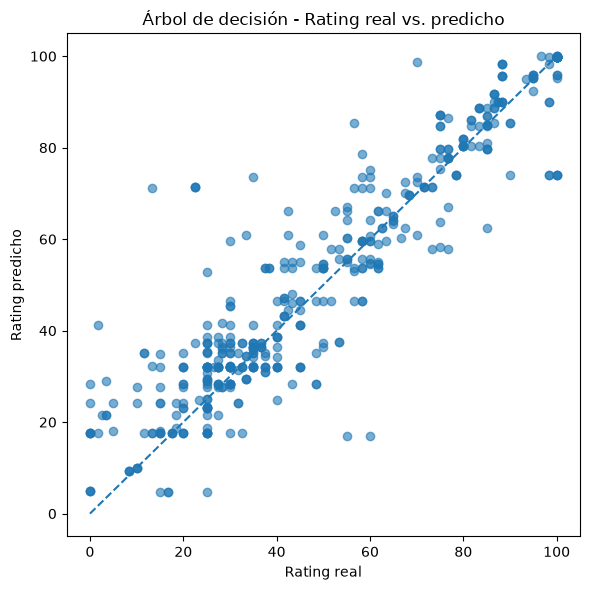

In [18]:
plt.figure(figsize=(6, 6))

plt.scatter(
    tree_validation_results_df[
        "rating_score_mean_t1"
    ],
    tree_validation_results_df[
        "prediction"
    ],
    alpha=0.6
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--"
)

plt.xlabel("Rating real")
plt.ylabel("Rating predicho")

plt.title(
    "Árbol de decisión - Rating real vs. predicho"
)

plt.tight_layout()
plt.show()

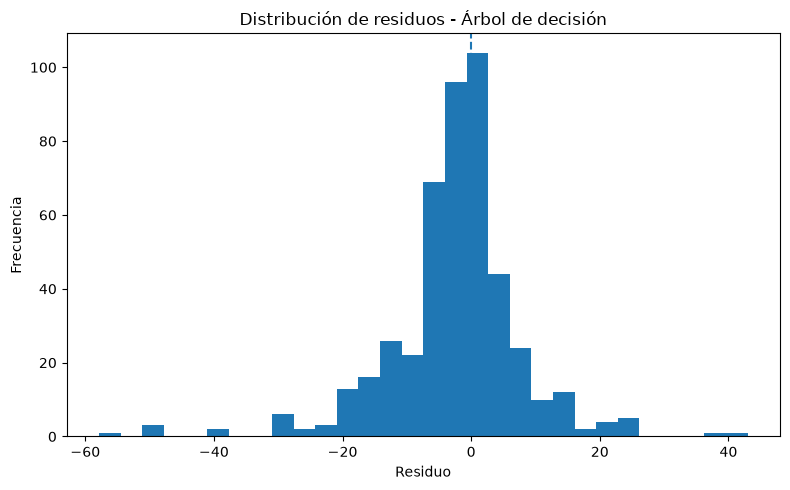

In [19]:
plt.figure(figsize=(8, 5))

plt.hist(
    tree_validation_results_df[
        "residual"
    ],
    bins=30
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residuo")
plt.ylabel("Frecuencia")

plt.title(
    "Distribución de residuos - Árbol de decisión"
)

plt.tight_layout()
plt.show()

In [20]:
tree_error_year = (
    tree_validation_results_df
    .groupby(
        "rating_year"
    )["absolute_error"]
    .mean()
)

display(
    tree_error_year
    .to_frame("MAE")
    .round(3)
)

,MAE
rating_year,
2020,5.823
2021,6.719
2022,8.090


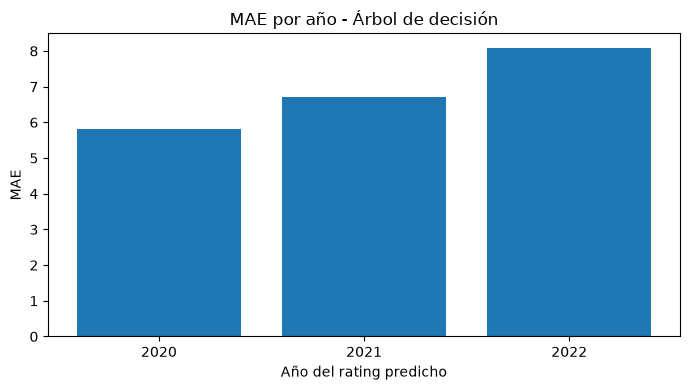

In [21]:
plt.figure(figsize=(7, 4))

plt.bar(
    tree_error_year.index.astype(str),
    tree_error_year.values
)

plt.xlabel(
    "Año del rating predicho"
)

plt.ylabel("MAE")

plt.title(
    "MAE por año - Árbol de decisión"
)

plt.tight_layout()
plt.show()

In [22]:
worst_tree_predictions = (
    tree_validation_results_df
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(15)
)

display(
    worst_tree_predictions[
        [
            "country",
            "year",
            "rating_year",
            "rating_score_mean_t1",
            "prediction",
            "absolute_error"
        ]
    ].round(2)
)

,country,year,rating_year,rating_score_mean_t1,prediction,absolute_error
2782,Russian Federation,2021,2022,13.33,71.19,57.86
521,Barbados,2020,2021,22.50,71.33,48.83
522,Barbados,2021,2022,22.50,71.33,48.83
520,Barbados,2019,2020,22.50,71.33,48.83
11,Aruba,2020,2021,60.00,17.02,42.98
409,Belarus,2021,2022,1.67,41.33,39.67
368,"Bahamas, The",2021,2022,35.00,73.67,38.67
1479,India,2020,2021,55.00,17.02,37.98
781,Costa Rica,2021,2022,30.00,59.58,29.58
1029,Spain,2019,2020,70.00,98.69,28.69


In [23]:
outside_tree = (
    (tree_validation_pred < 0)
    |
    (tree_validation_pred > 100)
)

print(
    "Predicciones fuera de 0-100:",
    outside_tree.sum()
)

print(
    "Porcentaje:",
    round(
        outside_tree.mean() * 100,
        2
    ),
    "%"
)

print(
    "Predicción mínima:",
    round(
        tree_validation_pred.min(),
        2
    )
)

print(
    "Predicción máxima:",
    round(
        tree_validation_pred.max(),
        2
    )
)

Predicciones fuera de 0-100: 0
Porcentaje: 0.0 %
Predicción mínima: 4.83
Predicción máxima: 100.0


In [24]:
tree_importance = pd.DataFrame({
    "variable":
        X_train_tree.columns,

    "importance":
        tree_model.feature_importances_
})

tree_importance = (
    tree_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    tree_importance
    .head(25)
    .round(4)
)

,variable,importance
0,years_since_last_default,0.6088
1,regulatory_quality_estimate,0.1225
2,government_effectiveness_estimate,0.0583
3,gdp_ppp_constant_2021_intl_usd,0.0418
4,gdp_per_capita_constant_2015_usd,0.0242
5,government_debt_pct_gdp,0.0160
6,government_debt_3y_change,0.0143
7,electoral_democracy_index,0.0134
8,missingindicator_inflation_abs,0.0100
9,missingindicator_electoral_democracy_index,0.0096


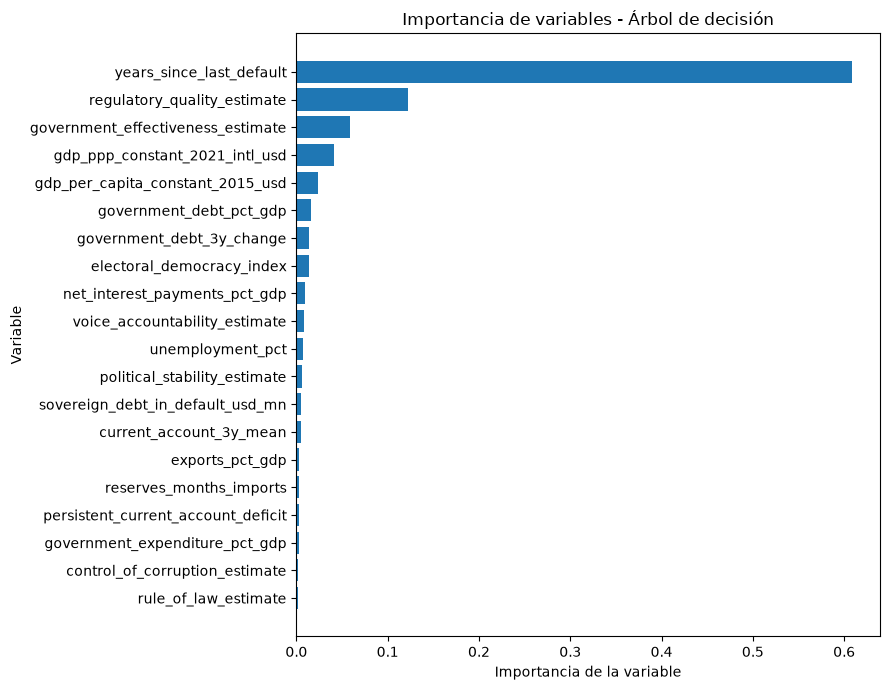

In [25]:
tree_importance_economic = (
    tree_importance[
        ~tree_importance["variable"]
        .str.startswith(
            "missingindicator_"
        )
    ]
)

top_tree_importance = (
    tree_importance_economic
    .head(20)
    .sort_values("importance")
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_tree_importance["variable"],
    top_tree_importance["importance"]
)

plt.xlabel(
    "Importancia de la variable"
)

plt.ylabel("Variable")

plt.title(
    "Importancia de variables - Árbol de decisión"
)

plt.tight_layout()
plt.show()

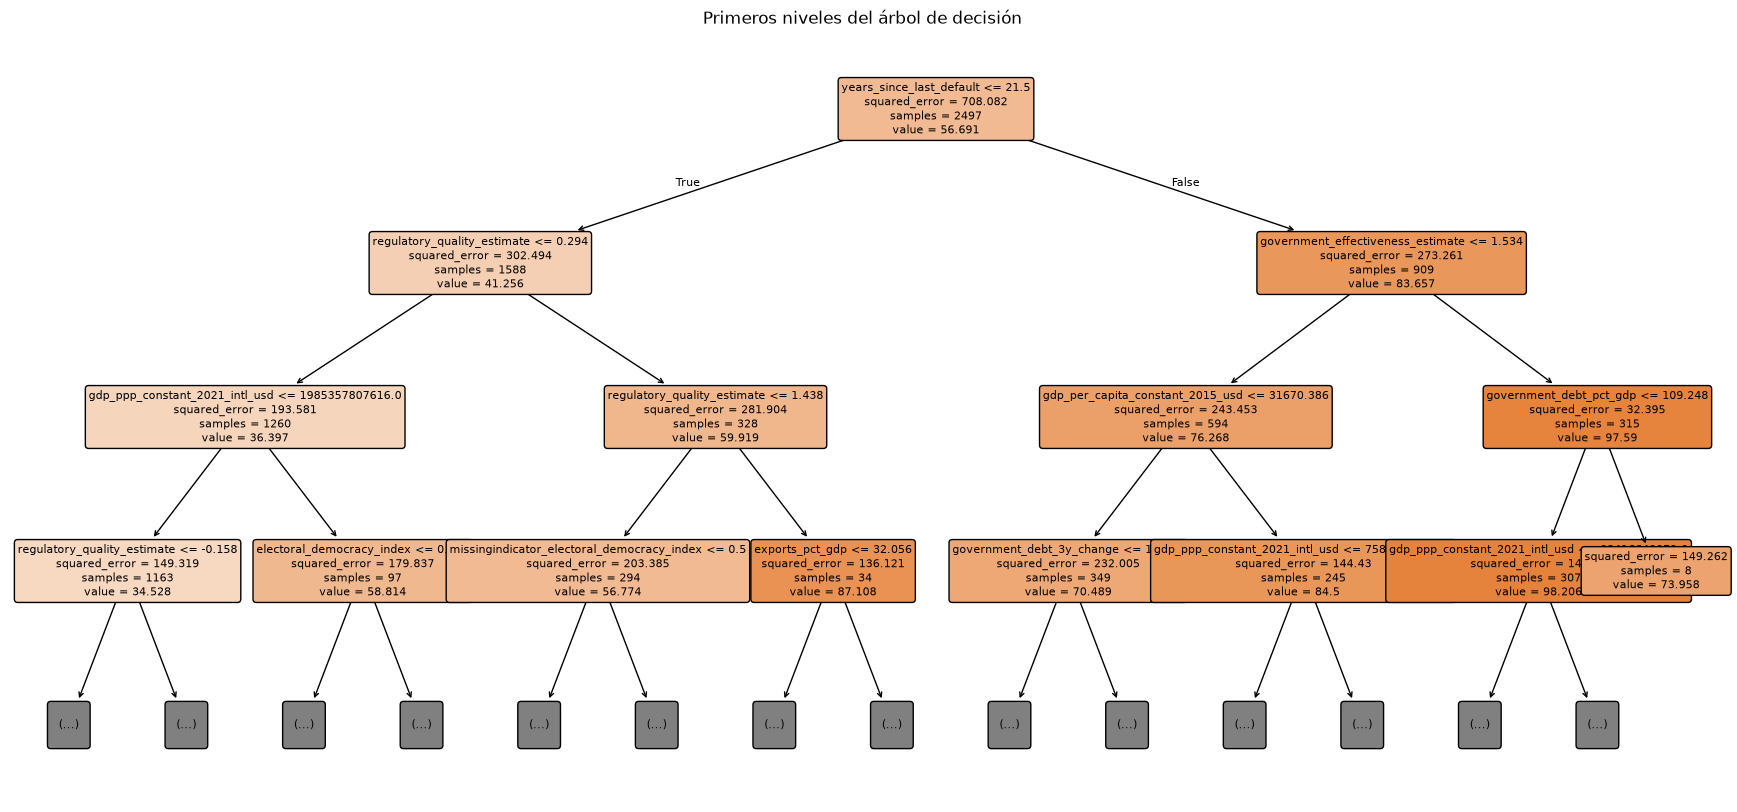

In [26]:
plt.figure(
    figsize=(22, 10)
)

plot_tree(
    tree_model,
    feature_names=
        X_train_tree.columns,

    filled=True,

    rounded=True,

    max_depth=3,

    fontsize=8
)

plt.title(
    "Primeros niveles del árbol de decisión"
)

plt.show()

### Resultados del Árbol de Decisión

El árbol de decisión definitivo alcanza un MAE de 6,880, un RMSE de 10,677 y un R² de 0,853 en el conjunto de validación. Aunque mejora en MAE a varios de los modelos lineales de la Rama A, no consigue superar a la red neuronal MLP, que continúa siendo el mejor modelo basado exclusivamente en fundamentales con un MAE de 6,056.

Tras restringir la complejidad del árbol para reducir el sobreajuste, la configuración final presenta una profundidad máxima de 10 niveles y 207 hojas. A pesar de esta regularización, continúa existiendo una diferencia relevante entre el error de entrenamiento y validación, característica habitual de los árboles individuales y que motiva posteriormente el uso de métodos ensemble como Random Forest y Extra Trees.

El análisis temporal vuelve a mostrar una pérdida progresiva de capacidad predictiva, con un MAE de 5,823 en 2020, 6,719 en 2021 y 8,090 en 2022. Por tanto, 2022 vuelve a constituir el periodo de mayor dificultad predictiva.

En términos de importancia, la variable `years_since_last_default` presenta un peso especialmente elevado, seguida por indicadores institucionales como la calidad regulatoria y la efectividad gubernamental. Esto confirma nuevamente la relevancia conjunta del historial de default y de la calidad institucional en la explicación de las calificaciones soberanas.

Una ventaja adicional respecto a los modelos de la Rama A es que el árbol no genera predicciones fuera del intervalo teórico 0-100. Las predicciones se sitúan entre 4,83 y 100, eliminando así una de las limitaciones observadas en las regresiones y en la red neuronal.

### Árbol de decisión + rating_t 
como estamods en la rama B, añadimos `rating_t`sin escalar

In [27]:
branch_A_results

{'comparison_fundamentals':                    MAE       RMSE        R2
 MLP           6.055701   8.620093  0.904040
 Lasso         7.167462  10.585936  0.855282
 Elastic Net   7.179068  10.586108  0.855277
 OLS original  7.260609  10.456483  0.858800
 Ridge         7.265357  10.423914  0.859678
 SVR           7.429994  10.712173  0.851810
 OLS depurada  8.486441  11.759899  0.821404,
 'comparison_rating':                              MAE      RMSE        R2
 Persistencia            1.505029  4.209194  0.977104
 Lasso + rating_t        2.086626  4.431901  0.974617
 Elastic Net + rating_t  2.115984  4.452206  0.974384
 OLS + rating_t          2.401590  4.520369  0.973594
 Ridge + rating_t        2.478716  4.617754  0.972444
 SVR + rating_t          2.914664  5.997070  0.953523
 MLP + rating_t          3.560960  5.338124  0.963176,
 'comparison_changed':                              MAE      RMSE        R2
 Ridge + rating_t        4.856655  7.815245  0.895051
 OLS + rating_t          4.9

In [28]:
comparison_rating_A = (
    branch_A_results["comparison_rating"]
)

comparison_changed_A = (
    branch_A_results["comparison_changed"]
)

In [29]:
display(
    comparison_rating_A.round(3)
)

display(
    comparison_changed_A.round(3)
)

,MAE,RMSE,R2
Persistencia,1.505,4.209,0.977
Lasso + rating_t,2.087,4.432,0.975
Elastic Net + rating_t,2.116,4.452,0.974
OLS + rating_t,2.402,4.520,0.974
Ridge + rating_t,2.479,4.618,0.972
SVR + rating_t,2.915,5.997,0.954
MLP + rating_t,3.561,5.338,0.963


,MAE,RMSE,R2
Ridge + rating_t,4.857,7.815,0.895
OLS + rating_t,4.951,7.736,0.897
Elastic Net + rating_t,4.965,7.855,0.894
Lasso + rating_t,4.981,7.857,0.894
Persistencia,5.097,7.746,0.897
SVR + rating_t,5.149,8.177,0.885
MLP + rating_t,5.689,8.021,0.889


In [30]:
train_rating_index = train[
    train["rating_score_mean_t"].notna()
].index

validation_rating_index = validation[
    validation["rating_score_mean_t"].notna()
].index

In [31]:
X_train_tree_rating = (
    X_train_B
    .loc[train_rating_index]
    .copy()
)

X_validation_tree_rating = (
    X_validation_B
    .loc[validation_rating_index]
    .copy()
)

y_train_tree_rating = (
    y_train.loc[train_rating_index]
)

y_validation_tree_rating = (
    y_validation.loc[validation_rating_index]
)

In [32]:
X_train_tree_rating[
    "rating_score_mean_t"
] = train.loc[
    train_rating_index,
    "rating_score_mean_t"
]

X_validation_tree_rating[
    "rating_score_mean_t"
] = validation.loc[
    validation_rating_index,
    "rating_score_mean_t"
]

In [33]:
print(
    "Train:",
    X_train_tree_rating.shape
)

print(
    "Validation:",
    X_validation_tree_rating.shape
)

print(
    "NaN train:",
    X_train_tree_rating.isna().sum().sum()
)

print(
    "NaN validation:",
    X_validation_tree_rating.isna().sum().sum()
)

Train: (2440, 144)
Validation: (464, 144)
NaN train: 0
NaN validation: 0


In [34]:
tree_rating_depths = [
    3,
    4,
    5,
    6,
    7,
    8,
    10
]

tree_rating_min_split = [
    10,
    20,
    30,
    50
]

tree_rating_min_leaf = [
    5,
    10,
    15,
    20,
    30
]

tree_rating_results = []

for max_depth in tree_rating_depths:

    for min_samples_split in tree_rating_min_split:

        for min_samples_leaf in tree_rating_min_leaf:

            model = DecisionTreeRegressor(
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf,
                random_state=42
            )

            model.fit(
                X_train_tree_rating,
                y_train_tree_rating
            )

            train_pred = model.predict(
                X_train_tree_rating
            )

            validation_pred = model.predict(
                X_validation_tree_rating
            )

            train_metrics = evaluate_model(
                y_train_tree_rating,
                train_pred
            )

            validation_metrics = evaluate_model(
                y_validation_tree_rating,
                validation_pred
            )

            tree_rating_results.append({
                "max_depth":
                    max_depth,

                "min_samples_split":
                    min_samples_split,

                "min_samples_leaf":
                    min_samples_leaf,

                "MAE_train":
                    train_metrics["MAE"],

                "MAE_validation":
                    validation_metrics["MAE"],

                "RMSE_validation":
                    validation_metrics["RMSE"],

                "R2_validation":
                    validation_metrics["R2"],

                "MAE_gap":
                    validation_metrics["MAE"]
                    - train_metrics["MAE"]
            })

tree_rating_validation_results = pd.DataFrame(
    tree_rating_results
)

In [35]:
display(
    tree_rating_validation_results
    .sort_values("MAE_validation")
    .head(15)
    .round(3)
)

,max_depth,min_samples_split,min_samples_leaf,MAE_train,MAE_validation,RMSE_validation,R2_validation,MAE_gap
49,5,20,30,1.932,2.490,4.913,0.969,0.559
54,5,30,30,1.932,2.490,4.913,0.969,0.559
59,5,50,30,1.932,2.490,4.913,0.969,0.559
44,5,10,30,1.932,2.490,4.913,0.969,0.559
74,6,30,30,1.883,2.591,4.921,0.969,0.708
79,6,50,30,1.883,2.591,4.921,0.969,0.708
69,6,20,30,1.883,2.591,4.921,0.969,0.708
64,6,10,30,1.883,2.591,4.921,0.969,0.708
99,7,50,30,1.886,2.635,4.931,0.969,0.749
84,7,10,30,1.886,2.635,4.931,0.969,0.749


In [36]:
best_tree_rating_row = (
    tree_rating_validation_results
    .sort_values("MAE_validation")
    .iloc[0]
)

best_tree_rating_depth = int(
    best_tree_rating_row["max_depth"]
)

best_tree_rating_min_split = int(
    best_tree_rating_row[
        "min_samples_split"
    ]
)

best_tree_rating_min_leaf = int(
    best_tree_rating_row[
        "min_samples_leaf"
    ]
)

print(
    "Mejor profundidad:",
    best_tree_rating_depth
)

print(
    "Mejor min_samples_split:",
    best_tree_rating_min_split
)

print(
    "Mejor min_samples_leaf:",
    best_tree_rating_min_leaf
)

display(
    best_tree_rating_row
    .to_frame()
    .T
    .round(3)
)

Mejor profundidad: 5
Mejor min_samples_split: 20
Mejor min_samples_leaf: 30


,max_depth,min_samples_split,min_samples_leaf,MAE_train,MAE_validation,RMSE_validation,R2_validation,MAE_gap
49,5.0,20.0,30.0,1.932,2.49,4.913,0.969,0.559


In [37]:
tree_model_rating = DecisionTreeRegressor(
    max_depth=best_tree_rating_depth,
    min_samples_split=
        best_tree_rating_min_split,
    min_samples_leaf=
        best_tree_rating_min_leaf,
    random_state=42
)

tree_model_rating.fit(
    X_train_tree_rating,
    y_train_tree_rating
)

tree_validation_pred_rating = (
    tree_model_rating.predict(
        X_validation_tree_rating
    )
)

tree_results_rating = evaluate_model(
    y_validation_tree_rating,
    tree_validation_pred_rating
)

display(
    pd.DataFrame(
        [tree_results_rating],
        index=[
            "Árbol + rating_t"
        ]
    ).round(3)
)

,MAE,RMSE,R2
Árbol + rating_t,2.49,4.913,0.969


In [38]:
comparison_rating_tree = (
    comparison_rating_A.copy()
)

comparison_rating_tree.loc[
    "Árbol + rating_t"
] = tree_results_rating

display(
    comparison_rating_tree
    .sort_values("MAE")
    .round(3)
)

,MAE,RMSE,R2
Persistencia,1.505,4.209,0.977
Lasso + rating_t,2.087,4.432,0.975
Elastic Net + rating_t,2.116,4.452,0.974
OLS + rating_t,2.402,4.520,0.974
Ridge + rating_t,2.479,4.618,0.972
Árbol + rating_t,2.490,4.913,0.969
SVR + rating_t,2.915,5.997,0.954
MLP + rating_t,3.561,5.338,0.963


In [39]:
changed_validation = validation.loc[
    validation_rating_index
].copy()

changed_validation[
    "rating_change_t1"
] = (
    changed_validation[
        "rating_score_mean_t1"
    ]
    - changed_validation[
        "rating_score_mean_t"
    ]
)

changed_validation = (
    changed_validation[
        changed_validation[
            "rating_change_t1"
        ] != 0
    ]
    .copy()
)

In [40]:
tree_rating_predictions = pd.Series(
    tree_validation_pred_rating,
    index=validation_rating_index
)

tree_changed_results = evaluate_model(
    changed_validation[
        "rating_score_mean_t1"
    ],
    tree_rating_predictions.loc[
        changed_validation.index
    ]
)

In [41]:
comparison_changed_tree = (
    comparison_changed_A.copy()
)

comparison_changed_tree.loc[
    "Árbol + rating_t"
] = tree_changed_results

display(
    comparison_changed_tree
    .sort_values("MAE")
    .round(3)
)

,MAE,RMSE,R2
Ridge + rating_t,4.857,7.815,0.895
OLS + rating_t,4.951,7.736,0.897
Elastic Net + rating_t,4.965,7.855,0.894
Lasso + rating_t,4.981,7.857,0.894
Árbol + rating_t,5.076,8.051,0.889
Persistencia,5.097,7.746,0.897
SVR + rating_t,5.149,8.177,0.885
MLP + rating_t,5.689,8.021,0.889


In [42]:
tree_rating_predictions = pd.Series(
    tree_validation_pred_rating,
    index=validation_rating_index
)

tree_changed_results = evaluate_model(
    changed_validation[
        "rating_score_mean_t1"
    ],
    tree_rating_predictions.loc[
        changed_validation.index
    ]
)

In [43]:
comparison_changed_tree = (
    comparison_changed_A.copy()
)

comparison_changed_tree.loc[
    "Árbol + rating_t"
] = tree_changed_results

display(
    comparison_changed_tree
    .sort_values("MAE")
    .round(3)
)

,MAE,RMSE,R2
Ridge + rating_t,4.857,7.815,0.895
OLS + rating_t,4.951,7.736,0.897
Elastic Net + rating_t,4.965,7.855,0.894
Lasso + rating_t,4.981,7.857,0.894
Árbol + rating_t,5.076,8.051,0.889
Persistencia,5.097,7.746,0.897
SVR + rating_t,5.149,8.177,0.885
MLP + rating_t,5.689,8.021,0.889


In [44]:
tree_rating_importance = pd.DataFrame({
    "variable":
        X_train_tree_rating.columns,

    "importance":
        tree_model_rating.feature_importances_
})

tree_rating_importance = (
    tree_rating_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    tree_rating_importance
    .head(20)
    .round(4)
)

,variable,importance
0,rating_score_mean_t,0.9984
1,government_debt_change,0.0004
2,missingindicator_persistent_current_account_de...,0.0003
3,government_debt_pct_gdp,0.0003
4,gdp_growth_3y_mean,0.0002
5,gdp_growth_pct,0.0002
6,primary_balance_pct_gdp,0.0001
7,primary_deficit_dummy,0.0001
8,exports_growth_3y_mean,0.0001
9,investment_pct_gdp,0.0000


### Conclusión del Árbol de Decisión

En conjunto, el árbol de decisión muestra una capacidad predictiva razonable a partir de los fundamentales, alcanzando un MAE de 6,880, aunque no consigue superar a la MLP, que continúa siendo el mejor modelo basado exclusivamente en variables fundamentales. Además, incluso después de limitar su complejidad, permanece una diferencia apreciable entre el rendimiento de entrenamiento y validación, lo que evidencia la tendencia del árbol individual al sobreajuste.

La incorporación de `rating_score_mean_t` mejora considerablemente la predicción del nivel futuro de la calificación. Sin embargo, el análisis de importancia revela que esta variable concentra prácticamente toda la capacidad explicativa del modelo, mientras que la contribución individual del resto de fundamentales resulta residual. Este comportamiento vuelve a poner de manifiesto la elevada persistencia temporal de las calificaciones crediticias.

Este resultado no debe considerarse un problema del modelo, sino una evidencia relevante para el análisis: cuando el objetivo consiste en predecir directamente el nivel de `rating_t+1`, el rating vigente puede absorber gran parte de la información predictiva disponible. Por ello, además de continuar con métodos ensemble capaces de reducir la varianza del árbol individual, posteriormente se realizará un análisis específico de los cambios de rating, con el objetivo de estudiar qué variables fundamentales permiten anticipar mejoras o deterioros de la calidad crediticia.

El siguiente modelo, Random Forest, permitirá comprobar si la agregación de múltiples árboles consigue reducir el sobreajuste observado y obtener una estructura predictiva más estable y diversificada.

## 8. RANDOM FOREST

> Octavo modelo real perteneciente a la RAMA B

Random Forest es un método ensemble basado en la combinación de múltiples árboles de decisión. Cada árbol se entrena sobre una muestra aleatoria de las observaciones y utiliza únicamente un subconjunto de las variables disponibles en cada división.

La agregación de las predicciones de numerosos árboles permite reducir la elevada varianza y el riesgo de sobreajuste característicos de un árbol de decisión individual, manteniendo al mismo tiempo la capacidad para capturar relaciones no lineales e interacciones complejas entre las variables.

Al pertenecer a la Rama B, el modelo se estima utilizando las variables sin estandarizar. La selección de hiperparámetros se realiza exclusivamente mediante el conjunto de validación, mientras que el conjunto de test permanece reservado para la evaluación final del modelo seleccionado.

Además del rendimiento predictivo, se analizará la diferencia entre entrenamiento y validación, la importancia de las variables y la estabilidad temporal de los errores.

In [45]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

X_train_rf = X_train_B.copy()
X_validation_rf = X_validation_B.copy()
X_test_rf = X_test_B.copy()

print("Train:", X_train_rf.shape)
print("Validation:", X_validation_rf.shape)
print("Test:", X_test_rf.shape)

Train: (2497, 143)
Validation: (466, 143)
Test: (471, 143)


In [46]:
rf_n_estimators = [
    200,
    500
]

rf_max_depths = [
    10,
    15,
    20,
    None
]

rf_min_samples_leaf = [
    1,
    5,
    10
]

rf_max_features = [
    "sqrt",
    0.5,
    1.0
]

rf_results = []

for n_estimators in rf_n_estimators:

    for max_depth in rf_max_depths:

        for min_samples_leaf in rf_min_samples_leaf:

            for max_features in rf_max_features:

                model = RandomForestRegressor(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    max_features=max_features,
                    random_state=42,
                    n_jobs=-1
                )

                model.fit(
                    X_train_rf,
                    y_train
                )

                train_pred = model.predict(
                    X_train_rf
                )

                validation_pred = model.predict(
                    X_validation_rf
                )

                train_metrics = evaluate_model(
                    y_train,
                    train_pred
                )

                validation_metrics = evaluate_model(
                    y_validation,
                    validation_pred
                )

                rf_results.append({
                    "n_estimators":
                        n_estimators,

                    "max_depth":
                        max_depth,

                    "min_samples_leaf":
                        min_samples_leaf,

                    "max_features":
                        max_features,

                    "MAE_train":
                        train_metrics["MAE"],

                    "MAE_validation":
                        validation_metrics["MAE"],

                    "RMSE_validation":
                        validation_metrics["RMSE"],

                    "R2_validation":
                        validation_metrics["R2"],

                    "MAE_gap":
                        validation_metrics["MAE"]
                        - train_metrics["MAE"]
                })

rf_validation_results = pd.DataFrame(
    rf_results
)

In [47]:
display(
    rf_validation_results
    .sort_values("MAE_validation")
    .head(15)
    .round(3)
)

,n_estimators,max_depth,min_samples_leaf,max_features,MAE_train,MAE_validation,RMSE_validation,R2_validation,MAE_gap
28,200,NaN,1,0.5,1.162,5.023,7.703,0.923,3.861
55,500,20.0,1,0.5,1.156,5.024,7.697,0.923,3.868
56,500,20.0,1,1.0,1.151,5.036,7.727,0.923,3.885
10,200,15.0,1,0.5,1.245,5.038,7.687,0.924,3.794
65,500,NaN,1,1.0,1.148,5.039,7.742,0.923,3.891
19,200,20.0,1,0.5,1.169,5.039,7.712,0.923,3.870
20,200,20.0,1,1.0,1.162,5.039,7.759,0.922,3.877
64,500,NaN,1,0.5,1.156,5.048,7.715,0.923,3.893
46,500,15.0,1,0.5,1.239,5.050,7.708,0.923,3.811
29,200,NaN,1,1.0,1.160,5.059,7.797,0.921,3.899


In [48]:
best_rf_row = (
    rf_validation_results
    .sort_values("MAE_validation")
    .iloc[0]
)

best_rf_n_estimators = int(
    best_rf_row["n_estimators"]
)

best_rf_depth = (
    None
    if pd.isna(
        best_rf_row["max_depth"]
    )
    else int(
        best_rf_row["max_depth"]
    )
)

best_rf_min_leaf = int(
    best_rf_row["min_samples_leaf"]
)

best_rf_max_features = (
    best_rf_row["max_features"]
)

print(
    "Mejor número de árboles:",
    best_rf_n_estimators
)

print(
    "Mejor profundidad:",
    best_rf_depth
)

print(
    "Mejor min_samples_leaf:",
    best_rf_min_leaf
)

print(
    "Mejor max_features:",
    best_rf_max_features
)

display(
    best_rf_row
    .to_frame()
    .T
)

Mejor número de árboles: 200
Mejor profundidad: None
Mejor min_samples_leaf: 1
Mejor max_features: 0.5


,n_estimators,max_depth,min_samples_leaf,max_features,MAE_train,MAE_validation,RMSE_validation,R2_validation,MAE_gap
28,200,NaN,1,0.5,1.162203,5.023364,7.702828,0.923376,3.861161


In [49]:
best_rf_row = (
    rf_validation_results
    .sort_values("MAE_validation")
    .iloc[0]
)

best_rf_n_estimators = int(
    best_rf_row["n_estimators"]
)

best_rf_depth = (
    None
    if pd.isna(
        best_rf_row["max_depth"]
    )
    else int(
        best_rf_row["max_depth"]
    )
)

best_rf_min_leaf = int(
    best_rf_row["min_samples_leaf"]
)

best_rf_max_features = (
    best_rf_row["max_features"]
)

print(
    "Mejor número de árboles:",
    best_rf_n_estimators
)

print(
    "Mejor profundidad:",
    best_rf_depth
)

print(
    "Mejor min_samples_leaf:",
    best_rf_min_leaf
)

print(
    "Mejor max_features:",
    best_rf_max_features
)

display(
    best_rf_row
    .to_frame()
    .T
)

Mejor número de árboles: 200
Mejor profundidad: None
Mejor min_samples_leaf: 1
Mejor max_features: 0.5


,n_estimators,max_depth,min_samples_leaf,max_features,MAE_train,MAE_validation,RMSE_validation,R2_validation,MAE_gap
28,200,NaN,1,0.5,1.162203,5.023364,7.702828,0.923376,3.861161


- `n_estimators = 200`: el bosque usa 200 árboles. 
- `max_depth = None`: cada árbol puede crecer todo lo necesario. Esto en un árbol individual sería preocupante, pero en Random Forest es menos grave porque cada árbol ve una muestra distinta y además no considera todas las variables en cada división.
- `min_samples_leaf = 1`: permite hojas con una sola observación. También es una configuración flexible y puede aumentar el sobreajuste de cada árbol individual.
- `max_features = 0.5`: en cada división cada árbol solo considera el 50 % de las variables. Como tienes unas 143 variables, serían aproximadamente 71 variables candidatas por split. Esto introduce diversidad entre árboles y es precisamente uno de los mecanismos que reduce el sobreajuste.

In [50]:
rf_model = RandomForestRegressor(
    n_estimators=
        best_rf_n_estimators,
    max_depth=
        best_rf_depth,
    min_samples_leaf=
        best_rf_min_leaf,
    max_features=
        best_rf_max_features,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_rf,
    y_train
)

rf_validation_pred = (
    rf_model.predict(
        X_validation_rf
    )
)

rf_results_final = evaluate_model(
    y_validation,
    rf_validation_pred
)

display(
    pd.DataFrame(
        [rf_results_final],
        index=["Random Forest"]
    ).round(3)
)

,MAE,RMSE,R2
Random Forest,5.023,7.703,0.923


In [51]:
rf_train_pred = rf_model.predict(
    X_train_rf
)

rf_train_results = evaluate_model(
    y_train,
    rf_train_pred
)

rf_overfit_comparison = pd.DataFrame({
    "Train":
        rf_train_results,

    "Validation":
        rf_results_final
}).T

display(
    rf_overfit_comparison.round(3)
)

,MAE,RMSE,R2
Train,1.162,1.903,0.995
Validation,5.023,7.703,0.923


In [52]:
comparison_models_rf = (
    comparison_models_all.copy()
)

comparison_models_rf.loc[
    "Random Forest"
] = rf_results_final

display(
    comparison_models_rf
    .sort_values("MAE")
    .round(3)
)

,MAE,RMSE,R2
Random Forest,5.023,7.703,0.923
MLP,6.056,8.620,0.904
Árbol de decisión,6.880,10.677,0.853
Lasso,7.167,10.586,0.855
Elastic Net,7.179,10.586,0.855
OLS original,7.261,10.456,0.859
Ridge,7.265,10.424,0.860
SVR,7.430,10.712,0.852
OLS depurada,8.486,11.760,0.821


In [53]:
rf_validation_results_df = validation[
    [
        "iso3",
        "country",
        "year",
        "rating_score_mean_t1"
    ]
].copy()

rf_validation_results_df[
    "rating_year"
] = (
    rf_validation_results_df["year"] + 1
)

rf_validation_results_df[
    "prediction"
] = rf_validation_pred

rf_validation_results_df[
    "residual"
] = (
    rf_validation_results_df[
        "rating_score_mean_t1"
    ]
    - rf_validation_results_df[
        "prediction"
    ]
)

rf_validation_results_df[
    "absolute_error"
] = (
    rf_validation_results_df[
        "residual"
    ].abs()
)

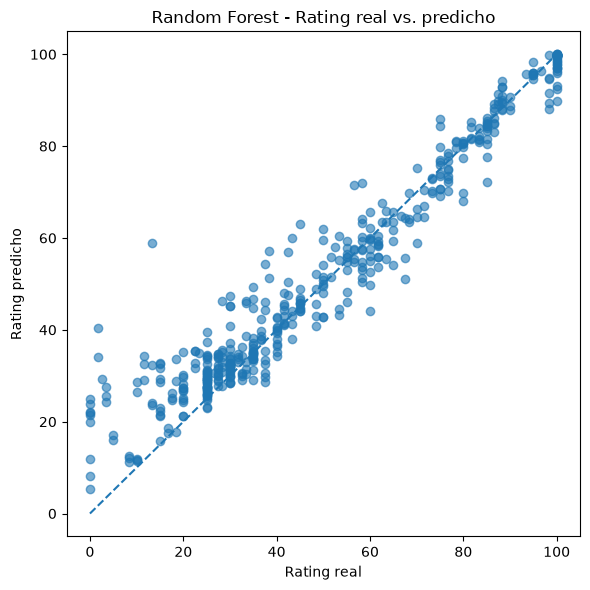

In [54]:
plt.figure(figsize=(6, 6))

plt.scatter(
    rf_validation_results_df[
        "rating_score_mean_t1"
    ],
    rf_validation_results_df[
        "prediction"
    ],
    alpha=0.6
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--"
)

plt.xlabel("Rating real")
plt.ylabel("Rating predicho")

plt.title(
    "Random Forest - Rating real vs. predicho"
)

plt.tight_layout()
plt.show()

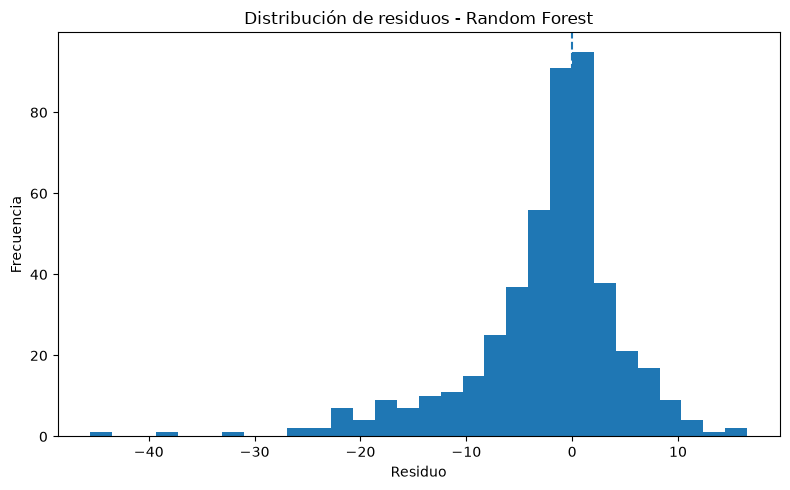

In [55]:
plt.figure(figsize=(8, 5))

plt.hist(
    rf_validation_results_df[
        "residual"
    ],
    bins=30
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residuo")
plt.ylabel("Frecuencia")

plt.title(
    "Distribución de residuos - Random Forest"
)

plt.tight_layout()
plt.show()

In [56]:
rf_error_year = (
    rf_validation_results_df
    .groupby(
        "rating_year"
    )["absolute_error"]
    .mean()
)

display(
    rf_error_year
    .to_frame("MAE")
    .round(3)
)

,MAE
rating_year,
2020,4.454
2021,4.710
2022,5.900


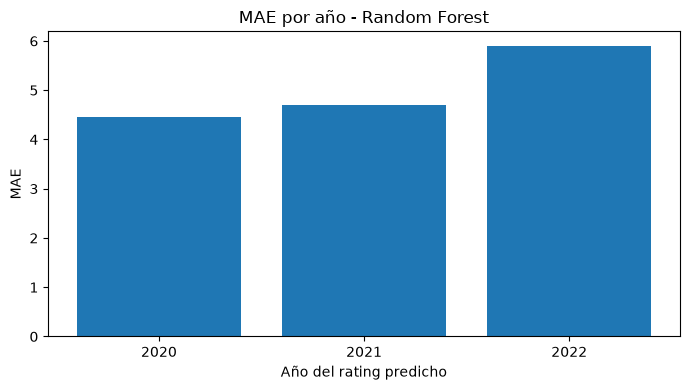

In [57]:
plt.figure(figsize=(7, 4))

plt.bar(
    rf_error_year.index.astype(str),
    rf_error_year.values
)

plt.xlabel(
    "Año del rating predicho"
)

plt.ylabel("MAE")

plt.title(
    "MAE por año - Random Forest"
)

plt.tight_layout()
plt.show()

In [58]:
worst_rf_predictions = (
    rf_validation_results_df
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(15)
)

display(
    worst_rf_predictions[
        [
            "country",
            "year",
            "rating_year",
            "rating_score_mean_t1",
            "prediction",
            "absolute_error"
        ]
    ].round(2)
)

,country,year,rating_year,rating_score_mean_t1,prediction,absolute_error
2782,Russian Federation,2021,2022,13.33,58.84,45.51
409,Belarus,2021,2022,1.67,40.45,38.78
1908,Sri Lanka,2021,2022,1.67,34.17,32.50
1229,Ghana,2021,2022,2.50,29.25,26.75
3430,Zambia,2021,2022,0.00,24.86,24.86
2979,Suriname,2019,2020,3.33,27.63,24.30
1844,Lebanon,2020,2021,0.00,23.86,23.86
3278,Ukraine,2021,2022,11.67,34.32,22.66
2981,Suriname,2021,2022,3.33,25.52,22.19
1845,Lebanon,2021,2022,0.00,22.16,22.16


In [59]:
outside_rf = (
    (rf_validation_pred < 0)
    |
    (rf_validation_pred > 100)
)

print(
    "Predicciones fuera de 0-100:",
    outside_rf.sum()
)

print(
    "Porcentaje:",
    round(
        outside_rf.mean() * 100,
        2
    ),
    "%"
)

print(
    "Predicción mínima:",
    round(
        rf_validation_pred.min(),
        2
    )
)

print(
    "Predicción máxima:",
    round(
        rf_validation_pred.max(),
        2
    )
)

Predicciones fuera de 0-100: 0
Porcentaje: 0.0 %
Predicción mínima: 5.32
Predicción máxima: 99.99


In [60]:
rf_importance = pd.DataFrame({
    "variable":
        X_train_rf.columns,

    "importance":
        rf_model.feature_importances_
})

rf_importance = (
    rf_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    rf_importance
    .head(25)
    .round(4)
)

,variable,importance
0,years_since_last_default,0.2872
1,never_default_history_dummy,0.1415
2,income_level_High income,0.1034
3,regulatory_quality_estimate,0.0810
4,gdp_per_capita_constant_2015_usd,0.0513
5,default_previous_10y,0.0473
6,government_effectiveness_estimate,0.0473
7,gdp_ppp_constant_2021_intl_usd,0.0327
8,government_debt_pct_gdp,0.0159
9,gdp_per_capita_ppp_constant_2021_intl_usd,0.0124


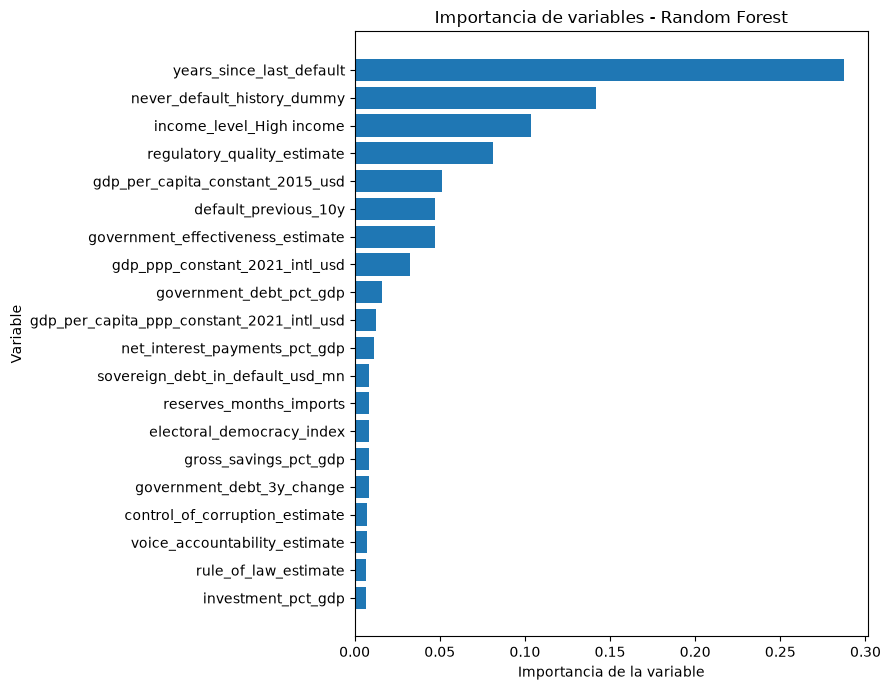

In [61]:
rf_importance_economic = (
    rf_importance[
        ~rf_importance["variable"]
        .str.startswith(
            "missingindicator_"
        )
    ]
)

top_rf_importance = (
    rf_importance_economic
    .head(20)
    .sort_values("importance")
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_rf_importance["variable"],
    top_rf_importance["importance"]
)

plt.xlabel(
    "Importancia de la variable"
)

plt.ylabel("Variable")

plt.title(
    "Importancia de variables - Random Forest"
)

plt.tight_layout()
plt.show()

In [62]:
rf_permutation = permutation_importance(
    rf_model,
    X_validation_rf,
    y_validation,
    scoring="neg_mean_absolute_error",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

rf_permutation_importance = pd.DataFrame({
    "variable":
        X_validation_rf.columns,

    "importance":
        rf_permutation.importances_mean
})

rf_permutation_importance = (
    rf_permutation_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    rf_permutation_importance
    .head(25)
    .round(4)
)

,variable,importance
0,regulatory_quality_estimate,4.1103
1,years_since_last_default,3.3150
2,gdp_ppp_constant_2021_intl_usd,2.0229
3,government_effectiveness_estimate,1.7608
4,gdp_per_capita_constant_2015_usd,1.5642
5,income_level_High income,1.4565
6,never_default_history_dummy,1.3239
7,government_debt_pct_gdp,0.9905
8,gdp_per_capita_ppp_constant_2021_intl_usd,0.5024
9,rule_of_law_estimate,0.4322


In [63]:
best_mae_rf = (
    rf_validation_results[
        "MAE_validation"
    ].min()
)

rf_candidates = (
    rf_validation_results[
        rf_validation_results[
            "MAE_validation"
        ] <= best_mae_rf * 1.02
    ]
    .sort_values("MAE_gap")
)

display(
    rf_candidates
    .head(15)
    .round(3)
)

,n_estimators,max_depth,min_samples_leaf,max_features,MAE_train,MAE_validation,RMSE_validation,R2_validation,MAE_gap
10,200,15.0,1,0.5,1.245,5.038,7.687,0.924,3.794
46,500,15.0,1,0.5,1.239,5.050,7.708,0.923,3.811
47,500,15.0,1,1.0,1.228,5.063,7.760,0.922,3.835
11,200,15.0,1,1.0,1.242,5.098,7.794,0.922,3.856
28,200,NaN,1,0.5,1.162,5.023,7.703,0.923,3.861
55,500,20.0,1,0.5,1.156,5.024,7.697,0.923,3.868
19,200,20.0,1,0.5,1.169,5.039,7.712,0.923,3.870
20,200,20.0,1,1.0,1.162,5.039,7.759,0.922,3.877
56,500,20.0,1,1.0,1.151,5.036,7.727,0.923,3.885
65,500,NaN,1,1.0,1.148,5.039,7.742,0.923,3.891


In [64]:
display(
    rf_candidates[
        [
            "n_estimators",
            "max_depth",
            "min_samples_leaf",
            "max_features",
            "MAE_train",
            "MAE_validation",
            "MAE_gap",
            "RMSE_validation",
            "R2_validation"
        ]
    ]
    .head(10)
    .round(3)
)

,n_estimators,max_depth,min_samples_leaf,max_features,MAE_train,MAE_validation,MAE_gap,RMSE_validation,R2_validation
10,200,15.0,1,0.5,1.245,5.038,3.794,7.687,0.924
46,500,15.0,1,0.5,1.239,5.050,3.811,7.708,0.923
47,500,15.0,1,1.0,1.228,5.063,3.835,7.760,0.922
11,200,15.0,1,1.0,1.242,5.098,3.856,7.794,0.922
28,200,NaN,1,0.5,1.162,5.023,3.861,7.703,0.923
55,500,20.0,1,0.5,1.156,5.024,3.868,7.697,0.923
19,200,20.0,1,0.5,1.169,5.039,3.870,7.712,0.923
20,200,20.0,1,1.0,1.162,5.039,3.877,7.759,0.922
56,500,20.0,1,1.0,1.151,5.036,3.885,7.727,0.923
65,500,NaN,1,1.0,1.148,5.039,3.891,7.742,0.923


Cambiamos a `depth=15`, ya que reduce el sobreajuste y mejora el RMSE y el $R^2$

In [65]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=1,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_rf,
    y_train
)

rf_validation_pred = rf_model.predict(
    X_validation_rf
)

rf_results_final = evaluate_model(
    y_validation,
    rf_validation_pred
)

display(
    pd.DataFrame(
        [rf_results_final],
        index=["Random Forest"]
    ).round(3)
)

,MAE,RMSE,R2
Random Forest,5.038,7.687,0.924


In [66]:
rf_train_pred = rf_model.predict(
    X_train_rf
)

rf_train_results = evaluate_model(
    y_train,
    rf_train_pred
)

rf_overfit_comparison = pd.DataFrame({
    "Train": rf_train_results,
    "Validation": rf_results_final
}).T

display(
    rf_overfit_comparison.round(3)
)

,MAE,RMSE,R2
Train,1.245,1.965,0.995
Validation,5.038,7.687,0.924


In [67]:
comparison_models_all.loc[
    "Random Forest"
] = rf_results_final

display(
    comparison_models_all
    .sort_values("MAE")
    .round(3)
)

,MAE,RMSE,R2
Random Forest,5.038,7.687,0.924
MLP,6.056,8.620,0.904
Árbol de decisión,6.880,10.677,0.853
Lasso,7.167,10.586,0.855
Elastic Net,7.179,10.586,0.855
OLS original,7.261,10.456,0.859
Ridge,7.265,10.424,0.860
SVR,7.430,10.712,0.852
OLS depurada,8.486,11.760,0.821


In [68]:
rf_best_params = {
    "n_estimators": 200,
    "max_depth": 15,
    "min_samples_leaf": 1,
    "max_features": 0.5
}

In [69]:
print(rf_best_params)

{'n_estimators': 200, 'max_depth': 15, 'min_samples_leaf': 1, 'max_features': 0.5}


### Conclusión del Random Forest con fundamentales

Random Forest mejora de forma clara el rendimiento del árbol de decisión individual y se convierte, hasta este punto, en el modelo con mejor capacidad predictiva utilizando exclusivamente variables fundamentales.

La configuración definitiva emplea 200 árboles, una profundidad máxima de 15, un mínimo de una observación por hoja y el 50 % de las variables disponibles en cada división. Esta configuración ofrece un compromiso adecuado entre capacidad predictiva y complejidad, ya que obtiene un rendimiento prácticamente idéntico al modelo sin restricción de profundidad, pero con una estructura algo más regularizada.

Aunque continúa existiendo una diferencia apreciable entre el error de entrenamiento y validación, la agregación de múltiples árboles permite reducir considerablemente el error fuera de muestra respecto al árbol individual. Además, la importancia de las variables se distribuye entre un conjunto más amplio de factores, proporcionando una interpretación económica más rica que la obtenida mediante un único árbol.

A continuación se incorpora el rating del periodo anterior (`rating_t`) para analizar hasta qué punto la elevada persistencia temporal de las calificaciones mejora la predicción y si Random Forest consigue mantener información adicional procedente de los fundamentales.

Ahora vamos con Random Forest + `rating_t`

In [70]:
X_train_rf_rating = (
    X_train_B
    .loc[train_rating_index]
    .copy()
)

X_validation_rf_rating = (
    X_validation_B
    .loc[validation_rating_index]
    .copy()
)

y_train_rf_rating = (
    y_train.loc[train_rating_index]
)

y_validation_rf_rating = (
    y_validation.loc[validation_rating_index]
)

X_train_rf_rating[
    "rating_score_mean_t"
] = train.loc[
    train_rating_index,
    "rating_score_mean_t"
]

X_validation_rf_rating[
    "rating_score_mean_t"
] = validation.loc[
    validation_rating_index,
    "rating_score_mean_t"
]

print(
    "Train:",
    X_train_rf_rating.shape
)

print(
    "Validation:",
    X_validation_rf_rating.shape
)

print(
    "NaN train:",
    X_train_rf_rating.isna().sum().sum()
)

print(
    "NaN validation:",
    X_validation_rf_rating.isna().sum().sum()
)

Train: (2440, 144)
Validation: (464, 144)
NaN train: 0
NaN validation: 0


In [71]:
rf_rating_n_estimators = [
    200,
    500
]

rf_rating_max_depths = [
    10,
    15,
    20,
    None
]

rf_rating_min_samples_leaf = [
    1,
    5,
    10
]

rf_rating_max_features = [
    "sqrt",
    0.5,
    1.0
]

rf_rating_results = []

for n_estimators in rf_rating_n_estimators:

    for max_depth in rf_rating_max_depths:

        for min_samples_leaf in rf_rating_min_samples_leaf:

            for max_features in rf_rating_max_features:

                model = RandomForestRegressor(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    max_features=max_features,
                    random_state=42,
                    n_jobs=-1
                )

                model.fit(
                    X_train_rf_rating,
                    y_train_rf_rating
                )

                train_pred = model.predict(
                    X_train_rf_rating
                )

                validation_pred = model.predict(
                    X_validation_rf_rating
                )

                train_metrics = evaluate_model(
                    y_train_rf_rating,
                    train_pred
                )

                validation_metrics = evaluate_model(
                    y_validation_rf_rating,
                    validation_pred
                )

                rf_rating_results.append({
                    "n_estimators":
                        n_estimators,

                    "max_depth":
                        max_depth,

                    "min_samples_leaf":
                        min_samples_leaf,

                    "max_features":
                        max_features,

                    "MAE_train":
                        train_metrics["MAE"],

                    "MAE_validation":
                        validation_metrics["MAE"],

                    "RMSE_validation":
                        validation_metrics["RMSE"],

                    "R2_validation":
                        validation_metrics["R2"],

                    "MAE_gap":
                        validation_metrics["MAE"]
                        - train_metrics["MAE"]
                })

rf_rating_validation_results = pd.DataFrame(
    rf_rating_results
)

In [72]:
display(
    rf_rating_validation_results
    .sort_values("MAE_validation")
    .head(15)
    .round(3)
)

,n_estimators,max_depth,min_samples_leaf,max_features,MAE_train,MAE_validation,RMSE_validation,R2_validation,MAE_gap
44,500,10.0,10,1.0,1.394,2.302,4.643,0.972,0.908
53,500,15.0,10,1.0,1.392,2.302,4.643,0.972,0.911
62,500,20.0,10,1.0,1.392,2.302,4.643,0.972,0.911
71,500,NaN,10,1.0,1.392,2.302,4.643,0.972,0.911
8,200,10.0,10,1.0,1.398,2.318,4.659,0.972,0.920
17,200,15.0,10,1.0,1.396,2.318,4.659,0.972,0.923
26,200,20.0,10,1.0,1.396,2.318,4.659,0.972,0.923
35,200,NaN,10,1.0,1.396,2.318,4.659,0.972,0.923
49,500,15.0,5,0.5,1.154,2.344,4.785,0.970,1.190
55,500,20.0,1,0.5,0.651,2.346,4.771,0.971,1.695


In [73]:
best_mae_rf_rating = (
    rf_rating_validation_results[
        "MAE_validation"
    ].min()
)

rf_rating_candidates = (
    rf_rating_validation_results[
        rf_rating_validation_results[
            "MAE_validation"
        ] <= best_mae_rf_rating * 1.02
    ]
    .sort_values("MAE_gap")
)

display(
    rf_rating_candidates[
        [
            "n_estimators",
            "max_depth",
            "min_samples_leaf",
            "max_features",
            "MAE_train",
            "MAE_validation",
            "MAE_gap",
            "RMSE_validation",
            "R2_validation"
        ]
    ]
    .head(15)
    .round(3)
)

,n_estimators,max_depth,min_samples_leaf,max_features,MAE_train,MAE_validation,MAE_gap,RMSE_validation,R2_validation
44,500,10.0,10,1.0,1.394,2.302,0.908,4.643,0.972
53,500,15.0,10,1.0,1.392,2.302,0.911,4.643,0.972
62,500,20.0,10,1.0,1.392,2.302,0.911,4.643,0.972
71,500,NaN,10,1.0,1.392,2.302,0.911,4.643,0.972
8,200,10.0,10,1.0,1.398,2.318,0.920,4.659,0.972
17,200,15.0,10,1.0,1.396,2.318,0.923,4.659,0.972
26,200,20.0,10,1.0,1.396,2.318,0.923,4.659,0.972
35,200,NaN,10,1.0,1.396,2.318,0.923,4.659,0.972
49,500,15.0,5,0.5,1.154,2.344,1.190,4.785,0.970
55,500,20.0,1,0.5,0.651,2.346,1.695,4.771,0.971


Le mejor combiancion es la sigueinte:
- n_estimators = 500
- max_depth = 10
 min_samples_leaf = 10
- max_features = 1.0

In [74]:
#cuando cambia le rating
rf_model_rating = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=10,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

rf_model_rating.fit(
    X_train_rf_rating,
    y_train_rf_rating
)

rf_validation_pred_rating = rf_model_rating.predict(
    X_validation_rf_rating
)

rf_results_rating = evaluate_model(
    y_validation_rf_rating,
    rf_validation_pred_rating
)

display(
    pd.DataFrame(
        [rf_results_rating],
        index=["Random Forest + rating_t"]
    ).round(3)
)

,MAE,RMSE,R2
Random Forest + rating_t,2.302,4.643,0.972


In [75]:
rf_rating_best_params = {
    "n_estimators": 500,
    "max_depth": 10,
    "min_samples_leaf": 10,
    "max_features": 1.0
}

In [76]:
comparison_rating_rf = (
    comparison_rating_A.copy()
)

comparison_rating_rf.loc[
    "Random Forest + rating_t"
] = rf_results_rating

display(
    comparison_rating_rf
    .sort_values("MAE")
    .round(3)
)

,MAE,RMSE,R2
Persistencia,1.505,4.209,0.977
Lasso + rating_t,2.087,4.432,0.975
Elastic Net + rating_t,2.116,4.452,0.974
Random Forest + rating_t,2.302,4.643,0.972
OLS + rating_t,2.402,4.520,0.974
Ridge + rating_t,2.479,4.618,0.972
SVR + rating_t,2.915,5.997,0.954
MLP + rating_t,3.561,5.338,0.963


In [77]:
rf_rating_predictions = pd.Series(
    rf_validation_pred_rating,
    index=validation_rating_index
)

rf_changed_results = evaluate_model(
    changed_validation[
        "rating_score_mean_t1"
    ],
    rf_rating_predictions.loc[
        changed_validation.index
    ]
)

display(
    pd.DataFrame(
        [rf_changed_results],
        index=[
            "Random Forest + rating_t"
        ]
    ).round(3)
)

,MAE,RMSE,R2
Random Forest + rating_t,4.86,7.762,0.896


In [78]:
comparison_changed_rf = (
    comparison_changed_A.copy()
)

comparison_changed_rf.loc[
    "Random Forest + rating_t"
] = rf_changed_results

display(
    comparison_changed_rf
    .sort_values("MAE")
    .round(3)
)

,MAE,RMSE,R2
Ridge + rating_t,4.857,7.815,0.895
Random Forest + rating_t,4.860,7.762,0.896
OLS + rating_t,4.951,7.736,0.897
Elastic Net + rating_t,4.965,7.855,0.894
Lasso + rating_t,4.981,7.857,0.894
Persistencia,5.097,7.746,0.897
SVR + rating_t,5.149,8.177,0.885
MLP + rating_t,5.689,8.021,0.889


In [79]:
rf_rating_importance = pd.DataFrame({
    "variable":
        X_train_rf_rating.columns,

    "importance":
        rf_model_rating.feature_importances_
})

rf_rating_importance = (
    rf_rating_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    rf_rating_importance
    .head(25)
    .round(4)
)

,variable,importance
0,rating_score_mean_t,0.9927
1,government_debt_change,0.0008
2,fiscal_balance_pct_gdp,0.0004
3,gdp_growth_3y_mean,0.0003
4,fiscal_balance_3y_mean,0.0003
5,primary_balance_pct_gdp,0.0003
6,government_debt_3y_change,0.0002
7,gdp_growth_pct,0.0002
8,unemployment_change,0.0002
9,gross_savings_pct_gdp,0.0002


In [80]:
rf_rating_permutation = permutation_importance(
    rf_model_rating,
    X_validation_rf_rating,
    y_validation_rf_rating,
    scoring="neg_mean_absolute_error",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

rf_rating_permutation_importance = pd.DataFrame({
    "variable":
        X_validation_rf_rating.columns,

    "importance":
        rf_rating_permutation.importances_mean
})

rf_rating_permutation_importance = (
    rf_rating_permutation_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    rf_rating_permutation_importance
    .head(25)
    .round(4)
)

,variable,importance
0,rating_score_mean_t,28.2555
1,fragile_states_index,0.0153
2,government_revenue_pct_gdp,0.0116
3,saving_investment_gap,0.0101
4,missingindicator_inflation_3y_std,0.0097
5,gross_savings_pct_gdp,0.0093
6,reserves_months_imports,0.0086
7,gdp_growth_pct,0.0072
8,current_account_3y_mean,0.0071
9,gdp_ppp_constant_2021_intl_usd,0.0058


### Conclusión del Random Forest

Random Forest supone una mejora importante respecto al árbol de decisión individual. Utilizando exclusivamente variables fundamentales, se convierte hasta este punto en el modelo con mejor capacidad predictiva de la Rama B, mostrando que la agregación de múltiples árboles permite reducir la inestabilidad del árbol individual y capturar relaciones no lineales de forma más robusta.

La incorporación de `rating_score_mean_t` reduce considerablemente el error de predicción y produce un modelo especialmente competitivo en aquellas observaciones en las que se registra un cambio efectivo de rating. En este subconjunto, Random Forest obtiene resultados prácticamente idénticos a Ridge, que continúa presentando el menor MAE, mientras que Random Forest alcanza un RMSE ligeramente inferior.

Sin embargo, el análisis de importancia de variables muestra que `rating_score_mean_t` concentra prácticamente toda la capacidad predictiva del modelo. Este resultado se confirma tanto mediante la importancia interna del Random Forest como mediante permutation importance, por lo que no parece tratarse únicamente de una característica del método de cálculo de importancia.

Los resultados refuerzan así la evidencia obtenida anteriormente: la elevada persistencia temporal de las calificaciones soberanas provoca que el rating vigente domine la predicción directa de `rating_t+1`. Por este motivo, una vez finalizada la comparación de los modelos principales, se realizará un análisis complementario centrado en la predicción del cambio de rating, donde el objetivo será identificar qué variables fundamentales permiten anticipar mejoras o deterioros de la calidad crediticia.

## 9. EXTRA TREES

> Noveno modelo real perteneciente a la RAMA B

Extra Trees es un método ensemble basado en la combinación de múltiples árboles de decisión. Su funcionamiento es similar a Random Forest, aunque introduce un grado adicional de aleatoriedad al seleccionar de forma más aleatoria los puntos de corte utilizados en las divisiones de cada árbol.

Esta mayor aleatorización puede reducir la varianza del modelo y mejorar su capacidad de generalización, aunque también puede aumentar ligeramente el sesgo. Al igual que Random Forest, permite capturar relaciones no lineales e interacciones entre variables y no requiere estandarización.

El modelo se estima utilizando exclusivamente variables fundamentales. Los principales hiperparámetros se seleccionan utilizando el conjunto de validación, manteniendo el conjunto de test completamente reservado para la evaluación final.

In [81]:
from sklearn.ensemble import ExtraTreesRegressor

X_train_et = X_train_B.copy()
X_validation_et = X_validation_B.copy()
X_test_et = X_test_B.copy()

print("Train:", X_train_et.shape)
print("Validation:", X_validation_et.shape)
print("Test:", X_test_et.shape)

Train: (2497, 143)
Validation: (466, 143)
Test: (471, 143)


In [82]:
et_max_depths = [
    10,
    15,
    20,
    None
]

et_min_samples_leaf = [
    1,
    3,
    5,
    10
]

et_max_features = [
    "sqrt",
    0.5,
    1.0
]

et_results = []

for max_depth in et_max_depths:

    for min_samples_leaf in et_min_samples_leaf:

        for max_features in et_max_features:

            model = ExtraTreesRegressor(
                n_estimators=300,
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                max_features=max_features,
                random_state=42,
                n_jobs=-1
            )

            model.fit(
                X_train_et,
                y_train
            )

            pred_train = model.predict(
                X_train_et
            )

            pred_validation = model.predict(
                X_validation_et
            )

            metrics_train = evaluate_model(
                y_train,
                pred_train
            )

            metrics_validation = evaluate_model(
                y_validation,
                pred_validation
            )

            et_results.append({
                "max_depth": max_depth,
                "min_samples_leaf": min_samples_leaf,
                "max_features": max_features,
                "MAE_train": metrics_train["MAE"],
                "MAE_validation": metrics_validation["MAE"],
                "RMSE_validation": metrics_validation["RMSE"],
                "R2_validation": metrics_validation["R2"],
                "MAE_gap":
                    metrics_validation["MAE"]
                    - metrics_train["MAE"]
            })

et_validation_results = pd.DataFrame(
    et_results
)

display(
    et_validation_results
    .sort_values("MAE_validation")
    .head(15)
    .round(3)
)

,max_depth,min_samples_leaf,max_features,MAE_train,MAE_validation,RMSE_validation,R2_validation,MAE_gap
38,NaN,1,1.0,0.000,4.855,7.771,0.922,4.855
26,20.0,1,1.0,0.067,4.879,7.800,0.921,4.811
25,20.0,1,0.5,0.087,4.984,7.911,0.919,4.897
37,NaN,1,0.5,0.000,4.999,7.919,0.919,4.999
14,15.0,1,1.0,0.516,5.005,7.892,0.920,4.489
41,NaN,3,1.0,0.840,5.019,7.929,0.919,4.179
29,20.0,3,1.0,0.848,5.070,7.973,0.918,4.222
17,15.0,3,1.0,1.086,5.099,7.988,0.918,4.013
13,15.0,1,0.5,0.628,5.238,8.142,0.914,4.611
28,20.0,3,0.5,1.042,5.278,8.174,0.914,4.236


In [83]:
best_mae_et = (
    et_validation_results[
        "MAE_validation"
    ].min()
)

et_candidates = (
    et_validation_results[
        et_validation_results[
            "MAE_validation"
        ] <= best_mae_et * 1.02
    ]
    .sort_values("MAE_gap")
)

display(
    et_candidates[
        [
            "max_depth",
            "min_samples_leaf",
            "max_features",
            "MAE_train",
            "MAE_validation",
            "MAE_gap",
            "RMSE_validation",
            "R2_validation"
        ]
    ]
    .head(15)
    .round(3)
)

,max_depth,min_samples_leaf,max_features,MAE_train,MAE_validation,MAE_gap,RMSE_validation,R2_validation
26,20.0,1,1.0,0.067,4.879,4.811,7.800,0.921
38,NaN,1,1.0,0.000,4.855,4.855,7.771,0.922


El segundo modelo tiene demasiado sobreajuste (MAE_train=0) por lo que nos decantaremos por el segundo.

In [84]:
et_model = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=1,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

et_model.fit(
    X_train_et,
    y_train
)

et_train_pred = et_model.predict(
    X_train_et
)

et_validation_pred = et_model.predict(
    X_validation_et
)

et_train_results = evaluate_model(
    y_train,
    et_train_pred
)

et_results_final = evaluate_model(
    y_validation,
    et_validation_pred
)

et_comparison = pd.DataFrame({
    "Train": et_train_results,
    "Validation": et_results_final
}).T

display(
    et_comparison.round(3)
)

,MAE,RMSE,R2
Train,0.067,0.147,1.000
Validation,4.879,7.800,0.921


In [85]:
comparison_models_all.loc[
    "Extra Trees"
] = et_results_final

display(
    comparison_models_all
    .sort_values("MAE")
    .round(3)
)

,MAE,RMSE,R2
Extra Trees,4.879,7.800,0.921
Random Forest,5.038,7.687,0.924
MLP,6.056,8.620,0.904
Árbol de decisión,6.880,10.677,0.853
Lasso,7.167,10.586,0.855
Elastic Net,7.179,10.586,0.855
OLS original,7.261,10.456,0.859
Ridge,7.265,10.424,0.860
SVR,7.430,10.712,0.852
OLS depurada,8.486,11.760,0.821


In [86]:
et_best_params = {
    "n_estimators": 300,
    "max_depth": 20,
    "min_samples_leaf": 1,
    "max_features": 1.0
}

In [87]:
outside_et = (
    (et_validation_pred < 0)
    |
    (et_validation_pred > 100)
)

print(
    "Predicciones fuera de 0-100:",
    outside_et.sum()
)

print(
    "Porcentaje:",
    round(outside_et.mean() * 100, 2),
    "%"
)

print(
    "Predicción mínima:",
    round(et_validation_pred.min(), 2)
)

print(
    "Predicción máxima:",
    round(et_validation_pred.max(), 2)
)

Predicciones fuera de 0-100: 0
Porcentaje: 0.0 %
Predicción mínima: 0.97
Predicción máxima: 100.0


In [88]:
et_importance = pd.DataFrame({
    "variable": X_train_et.columns,
    "importance": et_model.feature_importances_
})

et_importance = (
    et_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    et_importance
    .head(25)
    .round(4)
)

,variable,importance
0,never_default_history_dummy,0.4888
1,years_since_last_default,0.0996
2,regulatory_quality_estimate,0.0632
3,income_level_High income,0.0474
4,government_effectiveness_estimate,0.0272
5,sovereign_default_dummy,0.0168
6,gdp_ppp_constant_2021_intl_usd,0.0164
7,gdp_per_capita_constant_2015_usd,0.0143
8,government_debt_pct_gdp,0.0127
9,control_of_corruption_estimate,0.0124


In [89]:
et_permutation = permutation_importance(
    et_model,
    X_validation_et,
    y_validation,
    scoring="neg_mean_absolute_error",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

et_permutation_importance = pd.DataFrame({
    "variable":
        X_validation_et.columns,

    "importance":
        et_permutation.importances_mean
})

et_permutation_importance = (
    et_permutation_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    et_permutation_importance
    .head(25)
    .round(4)
)

,variable,importance
0,never_default_history_dummy,6.1760
1,regulatory_quality_estimate,4.0212
2,income_level_High income,2.8034
3,government_effectiveness_estimate,1.4411
4,sovereign_default_dummy,0.9668
5,gdp_ppp_constant_2021_intl_usd,0.8838
6,years_since_last_default,0.8376
7,gdp_per_capita_constant_2015_usd,0.8173
8,region_Latin America & Caribbean,0.7663
9,government_debt_pct_gdp,0.7618


### Conclusión de Extra Trees

Extra Trees obtiene un MAE de 4,879 en el conjunto de validación, convirtiéndose hasta este punto en el modelo con menor error absoluto medio utilizando exclusivamente variables fundamentales. El modelo mejora ligeramente a Random Forest en MAE, aunque presenta un RMSE algo superior y una diferencia considerable entre el error de entrenamiento y validación, evidenciando una elevada capacidad de ajuste sobre la muestra de entrenamiento.

A pesar de ello, su comportamiento fuera de muestra resulta competitivo y todas las predicciones permanecen dentro del intervalo válido de la escala de rating.

El análisis de importancia muestra un papel destacado del historial de impago soberano, especialmente a través de `never_default_history_dummy`, junto con variables relacionadas con la calidad institucional, el nivel de renta, el tamaño económico y la posición fiscal. La permutation importance confirma en términos generales esta estructura, aunque modifica el orden de algunas variables debido a la existencia de información compartida entre predictores relacionados.

En conjunto, Extra Trees muestra que la introducción de una mayor aleatoriedad en la construcción de los árboles puede mejorar la precisión media respecto a Random Forest, aunque continúa existiendo un riesgo relevante de sobreajuste. Su rendimiento se comparará posteriormente con los modelos de boosting antes de realizar la selección definitiva.

## 10. GRADIENT BOOSTING

> Décimo modelo real perteneciente a la RAMA B

Gradient Boosting es un método ensemble que construye árboles de decisión de forma secuencial. A diferencia de Random Forest y Extra Trees, donde los árboles se generan de manera independiente, cada nuevo árbol intenta corregir los errores cometidos por los árboles anteriores.

Este procedimiento permite construir progresivamente un modelo capaz de capturar relaciones no lineales e interacciones complejas entre las variables. Su rendimiento depende especialmente del número de árboles, la tasa de aprendizaje, la profundidad de los árboles y el número mínimo de observaciones por hoja.

El modelo se estima utilizando exclusivamente variables fundamentales. Los hiperparámetros se seleccionan mediante el conjunto de validación, manteniendo el conjunto de test reservado para la evaluación final.

In [90]:
from sklearn.ensemble import GradientBoostingRegressor

X_train_gb = X_train_B.copy()
X_validation_gb = X_validation_B.copy()
X_test_gb = X_test_B.copy()

print("Train:", X_train_gb.shape)
print("Validation:", X_validation_gb.shape)
print("Test:", X_test_gb.shape)

Train: (2497, 143)
Validation: (466, 143)
Test: (471, 143)


In [91]:
gb_n_estimators = [100, 200, 300]

gb_learning_rates = [
    0.03,
    0.05,
    0.1
]

gb_max_depths = [
    2,
    3,
    4
]

gb_min_samples_leaf = [
    5,
    10
]

gb_results = []

for n_estimators in gb_n_estimators:

    for learning_rate in gb_learning_rates:

        for max_depth in gb_max_depths:

            for min_samples_leaf in gb_min_samples_leaf:

                model = GradientBoostingRegressor(
                    n_estimators=n_estimators,
                    learning_rate=learning_rate,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    random_state=42
                )

                model.fit(
                    X_train_gb,
                    y_train
                )

                pred_train = model.predict(
                    X_train_gb
                )

                pred_validation = model.predict(
                    X_validation_gb
                )

                train_metrics = evaluate_model(
                    y_train,
                    pred_train
                )

                validation_metrics = evaluate_model(
                    y_validation,
                    pred_validation
                )

                gb_results.append({
                    "n_estimators": n_estimators,
                    "learning_rate": learning_rate,
                    "max_depth": max_depth,
                    "min_samples_leaf": min_samples_leaf,
                    "MAE_train": train_metrics["MAE"],
                    "MAE_validation": validation_metrics["MAE"],
                    "RMSE_validation": validation_metrics["RMSE"],
                    "R2_validation": validation_metrics["R2"],
                    "MAE_gap":
                        validation_metrics["MAE"]
                        - train_metrics["MAE"]
                })

gb_validation_results = pd.DataFrame(
    gb_results
)

display(
    gb_validation_results
    .sort_values("MAE_validation")
    .head(15)
    .round(3)
)

,n_estimators,learning_rate,max_depth,min_samples_leaf,MAE_train,MAE_validation,RMSE_validation,R2_validation,MAE_gap
53,300,0.10,4,10,1.444,5.323,7.847,0.920,3.880
52,300,0.10,4,5,1.371,5.417,7.844,0.921,4.045
35,200,0.10,4,10,1.943,5.435,7.961,0.918,3.491
34,200,0.10,4,5,1.906,5.503,7.928,0.919,3.597
46,300,0.05,4,5,2.246,5.516,8.005,0.917,3.270
47,300,0.05,4,10,2.318,5.569,8.005,0.917,3.251
51,300,0.10,3,10,2.375,5.570,8.030,0.917,3.194
50,300,0.10,3,5,2.337,5.607,7.989,0.918,3.270
40,300,0.03,4,5,2.963,5.648,8.239,0.912,2.685
28,200,0.05,4,5,2.822,5.689,8.268,0.912,2.867


In [92]:
best_mae_gb = (
    gb_validation_results[
        "MAE_validation"
    ].min()
)

gb_candidates = (
    gb_validation_results[
        gb_validation_results[
            "MAE_validation"
        ] <= best_mae_gb * 1.02
    ]
    .sort_values("MAE_gap")
)

display(
    gb_candidates[
        [
            "n_estimators",
            "learning_rate",
            "max_depth",
            "min_samples_leaf",
            "MAE_train",
            "MAE_validation",
            "MAE_gap",
            "RMSE_validation",
            "R2_validation"
        ]
    ]
    .head(15)
    .round(3)
)

,n_estimators,learning_rate,max_depth,min_samples_leaf,MAE_train,MAE_validation,MAE_gap,RMSE_validation,R2_validation
53,300,0.1,4,10,1.444,5.323,3.880,7.847,0.920
52,300,0.1,4,5,1.371,5.417,4.045,7.844,0.921


No mejora los otros modelos de arboles por lo que no compensa hacer una búsqueda enrome de los mejores parámetros.


In [93]:
gb_refined_results = []

for n_estimators in [300, 400]:

    for learning_rate in [0.075, 0.1]:

        for max_depth in [4, 5]:

            for subsample in [0.8, 1.0]:

                model = GradientBoostingRegressor(
                    n_estimators=n_estimators,
                    learning_rate=learning_rate,
                    max_depth=max_depth,
                    min_samples_leaf=10,
                    subsample=subsample,
                    random_state=42
                )

                model.fit(
                    X_train_gb,
                    y_train
                )

                pred_train = model.predict(
                    X_train_gb
                )

                pred_validation = model.predict(
                    X_validation_gb
                )

                train_metrics = evaluate_model(
                    y_train,
                    pred_train
                )

                validation_metrics = evaluate_model(
                    y_validation,
                    pred_validation
                )

                gb_refined_results.append({
                    "n_estimators": n_estimators,
                    "learning_rate": learning_rate,
                    "max_depth": max_depth,
                    "subsample": subsample,
                    "MAE_train": train_metrics["MAE"],
                    "MAE_validation": validation_metrics["MAE"],
                    "RMSE_validation": validation_metrics["RMSE"],
                    "R2_validation": validation_metrics["R2"],
                    "MAE_gap":
                        validation_metrics["MAE"]
                        - train_metrics["MAE"]
                })

gb_refined_results = pd.DataFrame(
    gb_refined_results
)

display(
    gb_refined_results
    .sort_values("MAE_validation")
    .head(10)
    .round(3)
)

,n_estimators,learning_rate,max_depth,subsample,MAE_train,MAE_validation,RMSE_validation,R2_validation,MAE_gap
10,400,0.075,5,0.8,0.765,4.916,7.354,0.930,4.151
15,400,0.100,5,1.0,0.584,4.933,7.404,0.929,4.349
2,300,0.075,5,0.8,1.040,4.942,7.381,0.930,3.902
14,400,0.100,5,0.8,0.561,4.951,7.413,0.929,4.390
7,300,0.100,5,1.0,0.816,4.971,7.440,0.929,4.155
6,300,0.100,5,0.8,0.798,4.976,7.425,0.929,4.178
11,400,0.075,5,1.0,0.829,5.092,7.475,0.928,4.263
3,300,0.075,5,1.0,1.145,5.136,7.524,0.927,3.991
13,400,0.100,4,1.0,1.112,5.244,7.781,0.922,4.132
8,400,0.075,4,0.8,1.358,5.297,7.716,0.923,3.940


In [94]:
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.075,
    max_depth=5,
    min_samples_leaf=10,
    subsample=0.8,
    random_state=42
)

gb_model.fit(
    X_train_gb,
    y_train
)

gb_train_pred = gb_model.predict(
    X_train_gb
)

gb_validation_pred = gb_model.predict(
    X_validation_gb
)

gb_train_results = evaluate_model(
    y_train,
    gb_train_pred
)

gb_results_final = evaluate_model(
    y_validation,
    gb_validation_pred
)

display(
    pd.DataFrame({
        "Train": gb_train_results,
        "Validation": gb_results_final
    }).T.round(3)
)

,MAE,RMSE,R2
Train,1.040,1.468,0.997
Validation,4.942,7.381,0.930


In [95]:
gb_best_params = {
    "n_estimators": 300,
    "learning_rate": 0.075,
    "max_depth": 5,
    "min_samples_leaf": 10,
    "subsample": 0.8
}

In [96]:
comparison_models_all.loc[
    "Gradient Boosting"
] = gb_results_final

display(
    comparison_models_all
    .sort_values("MAE")
    .round(3)
)

,MAE,RMSE,R2
Extra Trees,4.879,7.800,0.921
Gradient Boosting,4.942,7.381,0.930
Random Forest,5.038,7.687,0.924
MLP,6.056,8.620,0.904
Árbol de decisión,6.880,10.677,0.853
Lasso,7.167,10.586,0.855
Elastic Net,7.179,10.586,0.855
OLS original,7.261,10.456,0.859
Ridge,7.265,10.424,0.860
SVR,7.430,10.712,0.852


In [97]:
outside_gb = (
    (gb_validation_pred < 0)
    |
    (gb_validation_pred > 100)
)

print(
    "Predicciones fuera de 0-100:",
    outside_gb.sum()
)

print(
    "Porcentaje:",
    round(outside_gb.mean() * 100, 2),
    "%"
)

print(
    "Predicción mínima:",
    round(gb_validation_pred.min(), 2)
)

print(
    "Predicción máxima:",
    round(gb_validation_pred.max(), 2)
)

Predicciones fuera de 0-100: 6
Porcentaje: 1.29 %
Predicción mínima: 4.02
Predicción máxima: 100.55


In [98]:
gb_validation_results_df = (
    validation[
        [
            "iso3",
            "year",
            "rating_score_mean_t1"
        ]
    ]
    .copy()
)

gb_validation_results_df[
    "prediction"
] = gb_validation_pred

gb_validation_results_df[
    "absolute_error"
] = (
    gb_validation_results_df[
        "rating_score_mean_t1"
    ]
    -
    gb_validation_results_df[
        "prediction"
    ]
).abs()

gb_mae_by_year = (
    gb_validation_results_df
    .groupby("year")[
        "absolute_error"
    ]
    .mean()
)

display(
    gb_mae_by_year
    .to_frame("MAE")
    .round(3)
)

,MAE
year,
2019,4.309
2020,4.794
2021,5.718


In [99]:
gb_permutation = permutation_importance(
    gb_model,
    X_validation_gb,
    y_validation,
    scoring="neg_mean_absolute_error",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

gb_permutation_importance = pd.DataFrame({
    "variable":
        X_validation_gb.columns,

    "importance":
        gb_permutation.importances_mean
})

gb_permutation_importance = (
    gb_permutation_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    gb_permutation_importance
    .head(20)
    .round(4)
)

,variable,importance
0,years_since_last_default,4.1194
1,regulatory_quality_estimate,3.5880
2,gdp_ppp_constant_2021_intl_usd,2.6668
3,gdp_per_capita_constant_2015_usd,1.3814
4,government_debt_pct_gdp,1.0127
5,electoral_democracy_index,0.6370
6,government_effectiveness_estimate,0.5744
7,net_interest_payments_pct_gdp,0.5450
8,never_default_history_dummy,0.5369
9,reserves_months_imports,0.4609


### Conclusión de Gradient Boosting

Gradient Boosting presenta un rendimiento muy competitivo en la predicción del rating futuro a partir exclusivamente de variables fundamentales. La configuración finalmente seleccionada utiliza 300 árboles, una tasa de aprendizaje de 0,075, una profundidad máxima de 5, un mínimo de 10 observaciones por hoja y un `subsample` de 0,8.

En el conjunto de validación alcanza un MAE de 4,942, un RMSE de 7,381 y un R² de 0,930. Estos resultados lo sitúan entre los mejores modelos construidos hasta el momento. Aunque Extra Trees mantiene un MAE ligeramente inferior, de 4,879, Gradient Boosting obtiene un RMSE claramente menor y un R² superior, lo que indica una mejor capacidad para limitar los errores de mayor magnitud y reproducir la variabilidad observada en los ratings. :contentReference[oaicite:0]{index=0}

La diferencia entre el MAE de entrenamiento, 1,040, y el de validación, 4,942, muestra que todavía existe cierto sobreajuste. Sin embargo, el rendimiento obtenido sobre el periodo de validación temporal continúa siendo elevado, por lo que el modelo demuestra una capacidad de generalización considerable pese a esta diferencia entre ambas muestras. :contentReference[oaicite:1]{index=1}

En cuanto al rango de las predicciones, únicamente 6 observaciones, equivalentes al 1,29 % de la muestra de validación, se sitúan fuera de la escala teórica de 0 a 100. La predicción mínima es 4,02 y la máxima 100,55, por lo que las desviaciones respecto al intervalo permitido son muy reducidas. :contentReference[oaicite:2]{index=2}

El análisis mediante permutation importance proporciona además una interpretación económicamente coherente. Las variables con mayor contribución predictiva son `years_since_last_default`, `regulatory_quality_estimate`, el PIB en PPA, el PIB per cápita y la deuda pública sobre PIB. También aparecen entre las variables relevantes la democracia electoral, la efectividad gubernamental, los pagos netos de intereses, el historial de ausencia de default y las reservas internacionales. :contentReference[oaicite:3]{index=3}

Estos resultados muestran que Gradient Boosting combina información procedente de distintas dimensiones del riesgo soberano: historial de impago, calidad institucional, nivel de desarrollo económico, tamaño de la economía y posición fiscal. La relevancia conjunta de estos bloques refuerza la idea de que la calificación crediticia no depende de un único indicador, sino de la interacción entre características económicas, fiscales e institucionales.

En conjunto, Gradient Boosting se consolida como uno de los principales candidatos entre los modelos basados exclusivamente en fundamentales. Extra Trees continúa ofreciendo el menor MAE, mientras que Gradient Boosting presenta el mejor equilibrio hasta este punto en términos de RMSE y R². La selección definitiva deberá realizarse una vez incorporado XGBoost y comparados conjuntamente todos los modelos de la Rama B.

## 11. XGBOOST

> Undécimo modelo real perteneciente a la RAMA B

XGBoost es un método de boosting basado en árboles de decisión que construye los árboles de forma secuencial, de manera que cada nuevo árbol trata de corregir los errores cometidos por los anteriores.

A diferencia del Gradient Boosting tradicional, XGBoost incorpora mecanismos adicionales de regularización y optimización que permiten controlar mejor la complejidad del modelo y reducir el riesgo de sobreajuste. Entre sus principales hiperparámetros se encuentran el número de árboles, la tasa de aprendizaje, la profundidad máxima y el peso mínimo necesario para generar nuevas divisiones.

El modelo se estima utilizando exclusivamente variables fundamentales. Los hiperparámetros se seleccionan mediante el conjunto de validación temporal, mientras que el conjunto de test permanece completamente reservado para la evaluación final.

In [100]:
from xgboost import XGBRegressor

X_train_xgb = X_train_B.copy()
X_validation_xgb = X_validation_B.copy()
X_test_xgb = X_test_B.copy()

print("Train:", X_train_xgb.shape)
print("Validation:", X_validation_xgb.shape)
print("Test:", X_test_xgb.shape)

Train: (2497, 143)
Validation: (466, 143)
Test: (471, 143)


In [101]:
xgb_n_estimators = [
    300,
    500
]

xgb_learning_rates = [
    0.03,
    0.05,
    0.075
]

xgb_max_depths = [
    3,
    4
]

xgb_min_child_weights = [
    1,
    5
]

xgb_results = []

for n_estimators in xgb_n_estimators:

    for learning_rate in xgb_learning_rates:

        for max_depth in xgb_max_depths:

            for min_child_weight in xgb_min_child_weights:

                model = XGBRegressor(
                    n_estimators=n_estimators,
                    learning_rate=learning_rate,
                    max_depth=max_depth,
                    min_child_weight=min_child_weight,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    objective="reg:squarederror",
                    tree_method="hist",
                    random_state=42,
                    n_jobs=-1
                )

                model.fit(
                    X_train_xgb,
                    y_train
                )

                pred_train = model.predict(
                    X_train_xgb
                )

                pred_validation = model.predict(
                    X_validation_xgb
                )

                train_metrics = evaluate_model(
                    y_train,
                    pred_train
                )

                validation_metrics = evaluate_model(
                    y_validation,
                    pred_validation
                )

                xgb_results.append({
                    "n_estimators": n_estimators,
                    "learning_rate": learning_rate,
                    "max_depth": max_depth,
                    "min_child_weight": min_child_weight,
                    "MAE_train": train_metrics["MAE"],
                    "MAE_validation": validation_metrics["MAE"],
                    "RMSE_validation": validation_metrics["RMSE"],
                    "R2_validation": validation_metrics["R2"],
                    "MAE_gap":
                        validation_metrics["MAE"]
                        - train_metrics["MAE"]
                })

xgb_validation_results = pd.DataFrame(
    xgb_results
)

display(
    xgb_validation_results
    .sort_values("MAE_validation")
    .head(15)
    .round(3)
)

,n_estimators,learning_rate,max_depth,min_child_weight,MAE_train,MAE_validation,RMSE_validation,R2_validation,MAE_gap
22,500,0.075,4,1,0.986,5.113,7.488,0.928,4.127
18,500,0.050,4,1,1.449,5.122,7.476,0.928,3.674
23,500,0.075,4,5,0.994,5.157,7.476,0.928,4.164
19,500,0.050,4,5,1.458,5.168,7.561,0.926,3.710
10,300,0.075,4,1,1.598,5.236,7.652,0.924,3.638
14,500,0.030,4,1,2.097,5.263,7.661,0.924,3.166
15,500,0.030,4,5,2.130,5.265,7.681,0.924,3.135
11,300,0.075,4,5,1.588,5.305,7.659,0.924,3.717
6,300,0.050,4,1,2.150,5.308,7.728,0.923,3.158
20,500,0.075,3,1,1.959,5.310,7.637,0.925,3.351


In [102]:
best_mae_xgb = (
    xgb_validation_results[
        "MAE_validation"
    ].min()
)

xgb_candidates = (
    xgb_validation_results[
        xgb_validation_results[
            "MAE_validation"
        ] <= best_mae_xgb * 1.02
    ]
    .sort_values("MAE_gap")
)

display(
    xgb_candidates[
        [
            "n_estimators",
            "learning_rate",
            "max_depth",
            "min_child_weight",
            "MAE_train",
            "MAE_validation",
            "MAE_gap",
            "RMSE_validation",
            "R2_validation"
        ]
    ]
    .head(15)
    .round(3)
)

,n_estimators,learning_rate,max_depth,min_child_weight,MAE_train,MAE_validation,MAE_gap,RMSE_validation,R2_validation
18,500,0.050,4,1,1.449,5.122,3.674,7.476,0.928
19,500,0.050,4,5,1.458,5.168,3.710,7.561,0.926
22,500,0.075,4,1,0.986,5.113,4.127,7.488,0.928
23,500,0.075,4,5,0.994,5.157,4.164,7.476,0.928


In [103]:
xgb_best_params = {
    "n_estimators": 500,
    "learning_rate": 0.05,
    "max_depth": 4,
    "min_child_weight": 1,
    "subsample": 0.8,
    "colsample_bytree": 0.8
}

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_xgb,
    y_train
)

xgb_train_pred = xgb_model.predict(
    X_train_xgb
)

xgb_validation_pred = xgb_model.predict(
    X_validation_xgb
)

xgb_train_results = evaluate_model(
    y_train,
    xgb_train_pred
)

xgb_results_final = evaluate_model(
    y_validation,
    xgb_validation_pred
)

display(
    pd.DataFrame({
        "Train": xgb_train_results,
        "Validation": xgb_results_final
    }).T.round(3)
)

,MAE,RMSE,R2
Train,1.449,1.970,0.995
Validation,5.122,7.476,0.928


In [104]:
comparison_models_all.loc[
    "XGBoost"
] = xgb_results_final

display(
    comparison_models_all
    .sort_values("MAE")
    .round(3)
)

,MAE,RMSE,R2
Extra Trees,4.879,7.800,0.921
Gradient Boosting,4.942,7.381,0.930
Random Forest,5.038,7.687,0.924
XGBoost,5.122,7.476,0.928
MLP,6.056,8.620,0.904
Árbol de decisión,6.880,10.677,0.853
Lasso,7.167,10.586,0.855
Elastic Net,7.179,10.586,0.855
OLS original,7.261,10.456,0.859
Ridge,7.265,10.424,0.860


In [105]:
outside_xgb = (
    (xgb_validation_pred < 0)
    |
    (xgb_validation_pred > 100)
)

print(
    "Predicciones fuera de 0-100:",
    outside_xgb.sum()
)

print(
    "Porcentaje:",
    round(outside_xgb.mean() * 100, 2),
    "%"
)

print(
    "Predicción mínima:",
    round(xgb_validation_pred.min(), 2)
)

print(
    "Predicción máxima:",
    round(xgb_validation_pred.max(), 2)
)

Predicciones fuera de 0-100: 5
Porcentaje: 1.07 %
Predicción mínima: 2.31
Predicción máxima: 100.22


In [106]:
xgb_validation_results_df = validation[
    [
        "iso3",
        "year",
        "rating_score_mean_t1"
    ]
].copy()

xgb_validation_results_df[
    "prediction"
] = xgb_validation_pred

xgb_validation_results_df[
    "absolute_error"
] = (
    xgb_validation_results_df[
        "rating_score_mean_t1"
    ]
    -
    xgb_validation_results_df[
        "prediction"
    ]
).abs()

xgb_mae_by_year = (
    xgb_validation_results_df
    .groupby("year")[
        "absolute_error"
    ]
    .mean()
)

display(
    xgb_mae_by_year
    .to_frame("MAE")
    .round(3)
)

,MAE
year,
2019,4.468
2020,5.045
2021,5.849


In [107]:
xgb_permutation = permutation_importance(
    xgb_model,
    X_validation_xgb,
    y_validation,
    scoring="neg_mean_absolute_error",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

xgb_permutation_importance = pd.DataFrame({
    "variable":
        X_validation_xgb.columns,

    "importance":
        xgb_permutation.importances_mean
})

xgb_permutation_importance = (
    xgb_permutation_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    xgb_permutation_importance
    .head(20)
    .round(4)
)

,variable,importance
0,regulatory_quality_estimate,4.0527
1,years_since_last_default,3.3717
2,gdp_ppp_constant_2021_intl_usd,2.7173
3,gdp_per_capita_constant_2015_usd,1.6747
4,government_debt_pct_gdp,0.9759
5,never_default_history_dummy,0.7741
6,net_interest_payments_pct_gdp,0.6707
7,income_level_High income,0.5147
8,government_effectiveness_estimate,0.4237
9,reserves_months_imports,0.4001


### Conclusión de XGBoost

XGBoost alcanza un MAE de 5,122, un RMSE de 7,476 y un R² de 0,928 en el conjunto de validación temporal. Estos resultados sitúan al modelo entre los métodos con mayor capacidad predictiva del estudio, aunque no consigue superar el rendimiento alcanzado por Gradient Boosting.

La diferencia entre el error de entrenamiento y validación muestra la existencia de cierto sobreajuste. No obstante, el rendimiento fuera de muestra continúa siendo elevado y únicamente el 1,07 % de las predicciones se sitúa fuera del intervalo teórico de 0 a 100, con desviaciones muy reducidas respecto a dicho rango.

El análisis temporal muestra un incremento progresivo del error durante el periodo de validación, lo que sugiere que los años más recientes presentan una mayor dificultad predictiva.

La permutation importance identifica como variables especialmente relevantes la calidad regulatoria, los años transcurridos desde el último impago, el PIB en PPA, el PIB per cápita y la deuda pública sobre PIB. También aparecen entre las variables relevantes el historial de ausencia de default, los pagos netos de intereses, la efectividad gubernamental, las reservas internacionales y la democracia electoral.

La coincidencia de estas variables con las identificadas por otros modelos basados en árboles refuerza la robustez de la evidencia obtenida y sugiere que el riesgo soberano depende de una combinación de factores institucionales, económicos, fiscales y relacionados con el historial crediticio.

En conjunto, XGBoost ofrece un comportamiento sólido y un buen control de los errores de mayor magnitud, aunque Gradient Boosting presenta mejores resultados en las tres métricas principales de validación. Por este motivo, XGBoost no se considera el principal candidato de la Rama B, pero sí aporta evidencia adicional sobre la estabilidad de las variables fundamentales más relevantes.

## Selección del modelo definitivo

In [108]:
display(
    comparison_models_all
    .sort_values("MAE")
    .round(3)
)

,MAE,RMSE,R2
Extra Trees,4.879,7.800,0.921
Gradient Boosting,4.942,7.381,0.930
Random Forest,5.038,7.687,0.924
XGBoost,5.122,7.476,0.928
MLP,6.056,8.620,0.904
Árbol de decisión,6.880,10.677,0.853
Lasso,7.167,10.586,0.855
Elastic Net,7.179,10.586,0.855
OLS original,7.261,10.456,0.859
Ridge,7.265,10.424,0.860


Una vez finalizada la estimación de los modelos de la Rama B, los algoritmos basados en ensamblados presentan los mejores resultados predictivos. En concreto, Extra Trees, Gradient Boosting, XGBoost y Random Forest concentran los valores más reducidos de error y los mayores coeficientes de determinación, mostrando una capacidad predictiva claramente superior al resto de modelos analizados.

La selección del modelo definitivo no se realiza únicamente atendiendo a la mejor métrica individual, sino considerando conjuntamente la precisión predictiva, la capacidad de generalización y la adecuación del modelo al objetivo final del trabajo: generar predicciones de rating soberano directamente interpretables e incorporables a una herramienta interactiva.

La variable objetivo utilizada en este trabajo se encuentra definida en una escala comprendida entre 0 y 100, por lo que resulta especialmente relevante que las predicciones generadas permanezcan dentro de dicho intervalo. Este criterio permite evitar correcciones posteriores y garantiza que los resultados obtenidos sean coherentes con la escala utilizada para representar la calidad crediticia soberana.

Entre los modelos con mejor rendimiento predictivo se observan diferencias reducidas. Extra Trees obtiene el menor MAE de validación, con un valor de 4,879, seguido de Gradient Boosting (4,942), Random Forest (5,038) y XGBoost (5,122). Sin embargo, la diferencia entre estos modelos es reducida, lo que indica que todos ellos presentan una capacidad predictiva similar.

Al analizar el resto de métricas, Gradient Boosting obtiene el mejor comportamiento global en términos de ajuste, alcanzando un RMSE de 7,381 y un R² de 0,930. XGBoost presenta también resultados competitivos, con un RMSE de 7,476 y un R² de 0,928. Por su parte, Random Forest obtiene un RMSE de 7,687 y un R² de 0,924, manteniéndose dentro del grupo de modelos con mejor comportamiento predictivo.

A pesar de que algunos modelos presentan ligeras mejoras en determinadas métricas, la selección definitiva debe considerar también la estabilidad entre entrenamiento y validación. En este sentido, Extra Trees presenta una diferencia especialmente elevada entre ambas muestras, alcanzando un MAE prácticamente nulo en entrenamiento y aumentando hasta 4,879 en validación. Este comportamiento indica una capacidad muy elevada para adaptarse a los datos utilizados durante el ajuste, pero también un mayor riesgo de sobreajuste.

Por el contrario, Random Forest presenta un comportamiento más equilibrado, manteniendo un buen rendimiento predictivo fuera de muestra y una menor diferencia entre entrenamiento y validación. Aunque su MAE de validación es ligeramente superior al obtenido por Extra Trees, la pérdida de precisión es reducida y se compensa con una mayor estabilidad del modelo.

Además, Random Forest cumple el criterio adicional de generar predicciones dentro del intervalo válido de rating, evitando la necesidad de aplicar ajustes posteriores. Este aspecto resulta especialmente relevante para la implementación práctica del modelo dentro de la herramienta interactiva desarrollada en este trabajo.

Por tanto, aunque Gradient Boosting obtiene los mejores resultados según RMSE y R², y Extra Trees presenta el menor MAE, Random Forest se selecciona como modelo definitivo para la predicción del rating soberano a partir de variables fundamentales.

La elección se fundamenta en tres aspectos principales: presenta un rendimiento predictivo muy próximo al de los mejores modelos estimados, mantiene predicciones coherentes con la escala definida para el rating y ofrece un equilibrio más adecuado entre precisión y capacidad de generalización.

Esta decisión responde al objetivo aplicado del trabajo, donde no solo se busca maximizar el ajuste sobre los datos históricos, sino obtener un modelo robusto, estable e interpretable que pueda utilizarse para generar predicciones futuras de riesgo soberano.

La selección del modelo se realiza exclusivamente utilizando las muestras de entrenamiento y validación. El conjunto de test permanece completamente reservado y no interviene en esta fase. Una vez seleccionado Random Forest, el modelo será reestimado utilizando conjuntamente las muestras de entrenamiento y validación, realizando posteriormente una única evaluación final sobre el periodo de test.

In [109]:

from pathlib import Path
import joblib

MODEL_DATA_PATH = Path("data/model")

BRANCH_B_FILE = (
    MODEL_DATA_PATH
    / "notebook_4_3_branch_B_results.joblib"
)

branch_B_results = {
    "comparison_models_all": comparison_models_all,

    "selected_model": "Random Forest",

    "rf_best_params": rf_best_params,
    "rf_model": rf_model,
    "rf_results_final": rf_results_final,
    "rf_train_pred": rf_train_pred,
    "rf_validation_pred": rf_validation_pred,

    "et_best_params": et_best_params,
    "et_results_final": et_results_final,

    "gb_best_params": gb_best_params,
    "gb_results_final": gb_results_final,

    "xgb_best_params": xgb_best_params,
    "xgb_results_final": xgb_results_final
}

joblib.dump(
    branch_B_results,
    BRANCH_B_FILE
)

print(
    "Resultados de la Rama B guardados en:",
    BRANCH_B_FILE
)



Resultados de la Rama B guardados en: data\model\notebook_4_3_branch_B_results.joblib


In [110]:
check_branch_B = joblib.load(
    BRANCH_B_FILE
)

print(
    "Modelo seleccionado:",
    check_branch_B["selected_model"]
)

print(
    "\nParámetros Random Forest:"
)

print(
    check_branch_B["rf_best_params"]
)

display(
    check_branch_B[
        "comparison_models_all"
    ]
    .sort_values("MAE")
    .round(3)
)

Modelo seleccionado: Random Forest

Parámetros Random Forest:
{'n_estimators': 200, 'max_depth': 15, 'min_samples_leaf': 1, 'max_features': 0.5}


,MAE,RMSE,R2
Extra Trees,4.879,7.800,0.921
Gradient Boosting,4.942,7.381,0.930
Random Forest,5.038,7.687,0.924
XGBoost,5.122,7.476,0.928
MLP,6.056,8.620,0.904
Árbol de decisión,6.880,10.677,0.853
Lasso,7.167,10.586,0.855
Elastic Net,7.179,10.586,0.855
OLS original,7.261,10.456,0.859
Ridge,7.265,10.424,0.860


## Conclusión de la fase de selección de modelos

Tras comparar los modelos desarrollados en las Ramas A y B, Random Forest se selecciona como modelo definitivo para la predicción del rating soberano a partir de variables fundamentales.

La selección se realiza exclusivamente utilizando los conjuntos de entrenamiento y validación. Random Forest presenta una capacidad predictiva muy próxima a los mejores modelos estimados, mantiene todas sus predicciones dentro del intervalo válido de 0 a 100 y muestra un menor grado de sobreajuste que Extra Trees, su principal competidor.

A partir de este momento se considera cerrado el proceso de selección de modelos e hiperparámetros. El conjunto de test permanece completamente reservado y no ha intervenido en ninguna de las decisiones anteriores.

En el siguiente notebook se reestimará Random Forest utilizando conjuntamente las muestras de entrenamiento y validación y se realizará una única evaluación final sobre el periodo de test.